<a href="https://colab.research.google.com/github/ridhoakfa/Bike-Sharing-Dashboard/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Ridho Akbar Fadhilah
- **Email:** CDCC200D6Y1029@student.devacademy.id
- **ID Dicoding:** CDCC200D6Y1029

## Menentukan Pertanyaan Bisnis

- Bagaimana hubungan antara faktor lingkungan seperti suhu (temp), kelembapan (hum), dan kecepatan angin (windspeed) terhadap jumlah penyewaan sepeda (cnt) selama periode 2011–2012?
- Bagaimana variasi kondisi cuaca (weather_condition) dan musim (season_name) memengaruhi pola penggunaan layanan penyewaan sepeda selama periode 2011–2012, khususnya dalam perbandingan antar kategori?

## Import Semua Packages/Library yang Digunakan

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [2]:
# Download Dataset dari Kaggle
dataset_path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Dataset berhasil diunduh di:", dataset_path)

# Cek isi folder dataset
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

# Load Dataset
hour_df = pd.read_csv(os.path.join(dataset_path, "hour.csv"))
day_df = pd.read_csv(os.path.join(dataset_path, "day.csv"))

# Simpan Raw Data
raw_hour_df = hour_df.copy()
raw_day_df = day_df.copy()

# Preview data hour
hour_df.head()

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Dataset berhasil diunduh di: /kaggle/input/bike-sharing-dataset
/kaggle/input/bike-sharing-dataset/hour.csv
/kaggle/input/bike-sharing-dataset/Readme.txt
/kaggle/input/bike-sharing-dataset/day.csv


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
# Preview data day
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset terdiri dari dua jenis data utama, yaitu data penyewaan sepeda berbasis waktu per jam (`hour.csv`) dan per hari (`day.csv`).
- Informasi yang tersedia mencakup berbagai faktor seperti kondisi musim dan cuaca, di mana variabel `season` dan `weathersit` merepresentasikan kategori lingkungan, serta `temp` (suhu), `hum` (kelembapan), dan `windspeed` (kecepatan angin).
- Selain itu, dataset juga memuat informasi waktu seperti `year`, `month`, `hr`, `weekday`, serta kategori pengguna yaitu `casual` dan `registered`, yang memungkinkan analisis perilaku pengguna secara lebih mendalam.

### Assessing Data

In [4]:
# Menampilkan jumlah baris dan kolom pada masing-masing dataset

print("Informasi dataset hour.csv:")
print("Jumlah baris:", hour_df.shape[0])
print("Jumlah kolom:", hour_df.shape[1])

print("\nInformasi dataset day.csv:")
print("Jumlah baris:", day_df.shape[0])
print("Jumlah kolom:", day_df.shape[1])

Informasi dataset hour.csv:
Jumlah baris: 17379
Jumlah kolom: 17

Informasi dataset day.csv:
Jumlah baris: 731
Jumlah kolom: 16


In [5]:
print("Tipe data pada hour.csv:")
hour_df.info()

print("\nTipe data pada day.csv:")
day_df.info()

Tipe data pada hour.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Tipe data pada day.csv:

In [6]:
# Mengecek jumlah missing values pada dataset hour

missing_hour = hour_df.isna().sum()
print("Missing values pada hour.csv:")
display(missing_hour.to_frame(name="Jumlah Missing"))

Missing values pada hour.csv:


,Jumlah Missing
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [7]:
# Mengecek jumlah missing values pada dataset day

missing_day = day_df.isna().sum()
print("Missing values pada day.csv:")
display(missing_day.to_frame(name="Jumlah Missing"))

Missing values pada day.csv:


,Jumlah Missing
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [8]:
# Mengecek jumlah data duplikat

print("Jumlah data duplikat pada hour.csv:", hour_df.duplicated().sum())
print("Jumlah data duplikat pada day.csv:", day_df.duplicated().sum())

Jumlah data duplikat pada hour.csv: 0
Jumlah data duplikat pada day.csv: 0


In [9]:
# Mengidentifikasi outlier pada day.csv menggunakan metode IQR

Q1_day = day_df["cnt"].quantile(0.25)
Q3_day = day_df["cnt"].quantile(0.75)
IQR_day = Q3_day - Q1_day

lower_day = Q1_day - 1.5 * IQR_day
upper_day = Q3_day + 1.5 * IQR_day

outlier_day = day_df[(day_df["cnt"] < lower_day) | (day_df["cnt"] > upper_day)]

print("Jumlah outlier pada day.csv:", outlier_day.shape[0])
outlier_day.head()

Jumlah outlier pada day.csv: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


In [10]:
# Mengidentifikasi outlier pada hour.csv menggunakan metode IQR

Q1_hour = hour_df["cnt"].quantile(0.25)
Q3_hour = hour_df["cnt"].quantile(0.75)
IQR_hour = Q3_hour - Q1_hour

lower_hour = Q1_hour - 1.5 * IQR_hour
upper_hour = Q3_hour + 1.5 * IQR_hour

outlier_hour = hour_df[(hour_df["cnt"] < lower_hour) | (hour_df["cnt"] > upper_hour)]

print("Jumlah outlier pada hour.csv:", outlier_hour.shape[0])
outlier_hour.head()

Jumlah outlier pada hour.csv: 505


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
5536,5537,2011-08-23,3,0,8,14,0,2,1,1,0.72,0.6515,0.30,0.0896,149,502,651
10358,10359,2012-03-12,1,1,3,17,0,1,1,2,0.62,0.6212,0.38,0.4179,87,557,644
10359,10360,2012-03-12,1,1,3,18,0,1,1,2,0.60,0.6212,0.43,0.1940,89,623,712
10382,10383,2012-03-13,1,1,3,17,0,2,1,1,0.70,0.6364,0.37,0.1045,62,614,676
10383,10384,2012-03-13,1,1,3,18,0,2,1,1,0.70,0.6364,0.34,0.2985,96,638,734


**Insight:**

- **Informasi Dataset:**
  - Dataset `hour.csv` memiliki sebanyak **17.379 baris** dan **17 kolom** yang merepresentasikan data penyewaan sepeda dalam skala waktu per jam selama dua tahun.
  - Dataset `day.csv` memiliki sebanyak **731 baris** dan **16 kolom** yang merepresentasikan data penyewaan sepeda dalam skala harian.
  - Struktur kedua dataset relatif serupa, dengan perbedaan utama pada keberadaan variabel `hr` (jam) pada `hour.csv`.

- **Tipe Data:**
  - Sebagian besar variabel sudah memiliki tipe data yang sesuai (numerik), namun kolom `dteday` masih bertipe object sehingga perlu dikonversi menjadi datetime untuk analisis lebih lanjut.

- **Missing Values:**
  - Tidak ditemukan nilai yang hilang pada kedua dataset, sehingga tidak diperlukan penanganan missing values.

- **Duplikasi Data:**
  - Tidak terdapat data duplikat, sehingga seluruh data dapat digunakan tanpa perlu proses deduplikasi.

- **Outlier:**
  - Pada dataset `day.csv`, tidak ditemukan outlier pada variabel `cnt`, yang menunjukkan bahwa pola penyewaan harian cenderung stabil.
  - Pada dataset `hour.csv`, terdapat sejumlah outlier yang mengindikasikan adanya lonjakan atau penurunan jumlah penyewaan pada jam-jam tertentu.
  - Outlier tersebut kemungkinan berkaitan dengan jam sibuk (rush hour) atau kondisi tertentu seperti cuaca ekstrem.

### Cleaning Data

In [11]:
# Menghapus outlier pada dataset hour.csv berdasarkan batas IQR

print("Jumlah data sebelum menghapus outlier:", hour_df.shape)

hour_df = hour_df[(hour_df["cnt"] >= lower_hour) & (hour_df["cnt"] <= upper_hour)]

print("Jumlah data setelah menghapus outlier:", hour_df.shape)

Jumlah data sebelum menghapus outlier: (17379, 17)
Jumlah data setelah menghapus outlier: (16874, 17)


In [12]:
# Mengubah tipe data kolom dteday menjadi datetime
# Hal ini penting agar analisis berbasis waktu bisa dilakukan dengan lebih akurat

hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

In [13]:
# Menambahkan fitur berbasis waktu

# Dataset hourly
hour_df["year"] = hour_df["dteday"].dt.year
hour_df["month"] = hour_df["dteday"].dt.month
hour_df["day"] = hour_df["dteday"].dt.day
hour_df["day_of_week"] = hour_df["dteday"].dt.day_name()
hour_df["hour_of_day"] = hour_df["hr"]

# Dataset daily
day_df["year"] = day_df["dteday"].dt.year
day_df["month"] = day_df["dteday"].dt.month
day_df["day"] = day_df["dteday"].dt.day
day_df["day_of_week"] = day_df["dteday"].dt.day_name()

In [14]:
# Mengubah kode kategori menjadi label yang lebih mudah dipahami

# Mapping musim
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

# Mapping kondisi cuaca
weather_map = {
    1: "Cerah",
    2: "Berawan",
    3: "Hujan Ringan",
    4: "Hujan Lebat"
}

hour_df["season_name"] = hour_df["season"].map(season_map)
hour_df["weather_condition"] = hour_df["weathersit"].map(weather_map)

day_df["season_name"] = day_df["season"].map(season_map)
day_df["weather_condition"] = day_df["weathersit"].map(weather_map)

In [15]:
# Menghitung persentase pengguna casual dan registered

hour_df["casual_pct"] = hour_df["casual"] / hour_df["cnt"] * 100
hour_df["registered_pct"] = hour_df["registered"] / hour_df["cnt"] * 100

day_df["casual_pct"] = day_df["casual"] / day_df["cnt"] * 100
day_df["registered_pct"] = day_df["registered"] / day_df["cnt"] * 100

In [16]:
# Menampilkan ringkasan dataset setelah proses cleaning

print("Proses data cleaning selesai")

print("\nUkuran dataset hour.csv:", hour_df.shape)
print("Ukuran dataset day.csv:", day_df.shape)

print("\nInformasi hour.csv:")
hour_df.info()

print("\nInformasi day.csv:")
day_df.info()

# Preview dataset hourly
hour_df.head()

Proses data cleaning selesai

Ukuran dataset hour.csv: (16874, 26)
Ukuran dataset day.csv: (731, 24)

Informasi hour.csv:
<class 'pandas.core.frame.DataFrame'>
Index: 16874 entries, 0 to 17378
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            16874 non-null  int64         
 1   dteday             16874 non-null  datetime64[ns]
 2   season             16874 non-null  int64         
 3   yr                 16874 non-null  int64         
 4   mnth               16874 non-null  int64         
 5   hr                 16874 non-null  int64         
 6   holiday            16874 non-null  int64         
 7   weekday            16874 non-null  int64         
 8   workingday         16874 non-null  int64         
 9   weathersit         16874 non-null  int64         
 10  temp               16874 non-null  float64       
 11  atemp              16874 non-null  float64       
 12 

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,cnt,year,month,day,day_of_week,hour_of_day,season_name,weather_condition,casual_pct,registered_pct
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,16,2011,1,1,Saturday,0,Spring,Cerah,18.750000,81.250000
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,40,2011,1,1,Saturday,1,Spring,Cerah,20.000000,80.000000
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,32,2011,1,1,Saturday,2,Spring,Cerah,15.625000,84.375000
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,13,2011,1,1,Saturday,3,Spring,Cerah,23.076923,76.923077
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,1,2011,1,1,Saturday,4,Spring,Cerah,0.000000,100.000000


In [17]:
# Preview dataset daily

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,registered,cnt,year,month,day,day_of_week,season_name,weather_condition,casual_pct,registered_pct
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,654,985,2011,1,1,Saturday,Spring,Berawan,33.604061,66.395939
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,670,801,2011,1,2,Sunday,Spring,Berawan,16.354557,83.645443
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,1229,1349,2011,1,3,Monday,Spring,Cerah,8.895478,91.104522
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,1454,1562,2011,1,4,Tuesday,Spring,Cerah,6.914213,93.085787
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,1518,1600,2011,1,5,Wednesday,Spring,Cerah,5.125000,94.875000


**Insight:**

- **Penanganan Outlier:**
  - Outlier pada variabel `cnt` di dataset `hour.csv` telah dihapus menggunakan metode IQR untuk mengurangi pengaruh nilai ekstrem terhadap analisis.
  - Penghapusan ini menyebabkan jumlah data berkurang, namun meningkatkan kualitas dan kestabilan pola data.

- **Perubahan Tipe Data:**
  - Kolom `dteday` pada kedua dataset berhasil dikonversi menjadi tipe datetime sehingga memungkinkan analisis berbasis waktu secara lebih akurat.

- **Feature Engineering:**
  - Ditambahkan beberapa variabel baru seperti `year`, `month`, `day`, dan `day_of_week` untuk memperkaya analisis temporal.
  - Variabel `hour_of_day` pada `hour.csv` memberikan detail tambahan terkait pola penggunaan dalam satu hari.

- **Transformasi Kategori:**
  - Variabel kategorikal seperti `season` dan `weathersit` diubah menjadi label yang lebih deskriptif melalui `season_name` dan `weather_condition`.
  - Transformasi ini membantu meningkatkan keterbacaan dan interpretasi hasil analisis.

- **Proporsi Pengguna:**
  - Perhitungan persentase `casual` dan `registered` memberikan gambaran kontribusi masing-masing tipe pengguna terhadap total penyewaan.

- **Kondisi Dataset Setelah Cleaning:**
  - Dataset menjadi lebih bersih, terstruktur, dan siap digunakan untuk analisis eksploratif maupun visualisasi lebih lanjut.

## Exploratory Data Analysis (EDA)

### Statistik Deskriptif & Korelasi

In [18]:
# Statistik deskriptif untuk data numerik (hour)
print("Statistik Deskriptif Data Hour:")
hour_df.describe().T

Statistik Deskriptif Data Hour:


,count,mean,min,25%,50%,75%,max,std
instant,16874.0,8542.168899,1.0,4219.25,8438.5,12832.75,17379.0,5007.76604
dteday,16874,2011-12-26 23:54:06.699063808,2011-01-01 00:00:00,2011-06-29 00:00:00,2011-12-23 00:00:00,2012-06-23 00:00:00,2012-12-31 00:00:00,NaN
season,16874.0,2.490399,1.0,1.0,2.0,3.0,4.0,1.111966
yr,16874.0,0.487733,0.0,0.0,0.0,1.0,1.0,0.499864
mnth,16874.0,6.513275,1.0,4.0,7.0,10.0,12.0,3.462438
hr,16874.0,11.458101,0.0,5.0,11.0,18.0,23.0,6.962144
holiday,16874.0,0.029513,0.0,0.0,0.0,0.0,1.0,0.169244
weekday,16874.0,2.997748,0.0,1.0,3.0,5.0,6.0,2.013054
workingday,16874.0,0.678618,0.0,0.0,1.0,1.0,1.0,0.467021
weathersit,16874.0,1.430663,1.0,1.0,1.0,2.0,4.0,0.642689


In [19]:
# Statistik deskriptif untuk data numerik (day)
print("Statistik Deskriptif Data Day:")
day_df.describe().T

Statistik Deskriptif Data Day:


,count,mean,min,25%,50%,75%,max,std
instant,731.0,366.0,1.0,183.5,366.0,548.5,731.0,211.165812
dteday,731,2012-01-01 00:00:00,2011-01-01 00:00:00,2011-07-02 12:00:00,2012-01-01 00:00:00,2012-07-01 12:00:00,2012-12-31 00:00:00,NaN
season,731.0,2.49658,1.0,2.0,3.0,3.0,4.0,1.110807
yr,731.0,0.500684,0.0,0.0,1.0,1.0,1.0,0.500342
mnth,731.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
holiday,731.0,0.028728,0.0,0.0,0.0,0.0,1.0,0.167155
weekday,731.0,2.997264,0.0,1.0,3.0,5.0,6.0,2.004787
workingday,731.0,0.683995,0.0,0.0,1.0,1.0,1.0,0.465233
weathersit,731.0,1.395349,1.0,1.0,1.0,2.0,3.0,0.544894
temp,731.0,0.495385,0.05913,0.337083,0.498333,0.655417,0.861667,0.183051


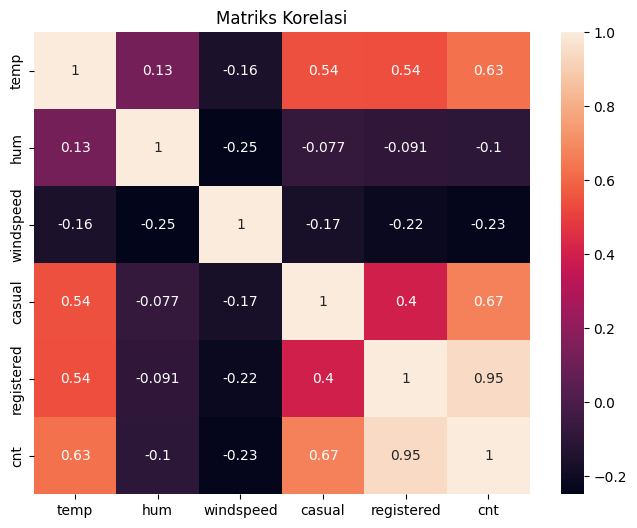


Matriks Korelasi:
                temp       hum  windspeed    casual  registered       cnt
temp        1.000000  0.126963  -0.157944  0.543285    0.540012  0.627494
hum         0.126963  1.000000  -0.248489 -0.077008   -0.091089 -0.100659
windspeed  -0.157944 -0.248489   1.000000 -0.167613   -0.217449 -0.234545
casual      0.543285 -0.077008  -0.167613  1.000000    0.395282  0.672804
registered  0.540012 -0.091089  -0.217449  0.395282    1.000000  0.945517
cnt         0.627494 -0.100659  -0.234545  0.672804    0.945517  1.000000


In [20]:
# Korelasi antar variabel numerik
corr_matrix = day_df[['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Matriks Korelasi")
plt.show()

print("\nMatriks Korelasi:")
print(corr_matrix)

**Insight:**

* **Statistik Deskriptif:**

  * Pada data per jam (`hour_df`), rata-rata jumlah penyewaan sepeda sekitar 172 unit per jam, dengan nilai maksimum mencapai lebih dari 600, menunjukkan adanya lonjakan penggunaan pada waktu-waktu tertentu.
  * Pada data harian (`day_df`), rata-rata penyewaan mencapai sekitar 4.500 sepeda per hari, dengan variasi yang cukup besar antara hari dengan permintaan rendah dan tinggi.
  * Pengguna terdaftar (registered) secara konsisten jauh lebih banyak dibandingkan pengguna kasual, baik pada data per jam maupun per hari, yang menunjukkan dominasi pengguna tetap dalam sistem.
  * Variabel suhu berada di sekitar nilai tengah (±0.49), menandakan kondisi cuaca yang cukup bervariasi sepanjang periode observasi.

* **Analisis Korelasi:**

  * Suhu (`temp`) memiliki hubungan positif yang cukup kuat dengan jumlah penyewaan sepeda (`cnt`), yang berarti semakin tinggi suhu, semakin meningkat jumlah penyewaan.
  * Kelembapan (`hum`) menunjukkan korelasi negatif yang lemah terhadap jumlah penyewaan, sehingga pengaruhnya tidak terlalu signifikan.
  * Kecepatan angin (`windspeed`) memiliki hubungan negatif yang lebih terlihat dibandingkan kelembapan, yang mengindikasikan bahwa angin kencang dapat menurunkan minat bersepeda.
  * Jumlah pengguna terdaftar (`registered`) memiliki korelasi yang sangat tinggi dengan total penyewaan, menandakan bahwa kontribusi utama berasal dari pengguna tetap.
  * Pengguna kasual (`casual`) juga memiliki korelasi positif, namun tidak sekuat pengguna terdaftar.

### EDA Univariate (Analisis Variabel Tunggal)

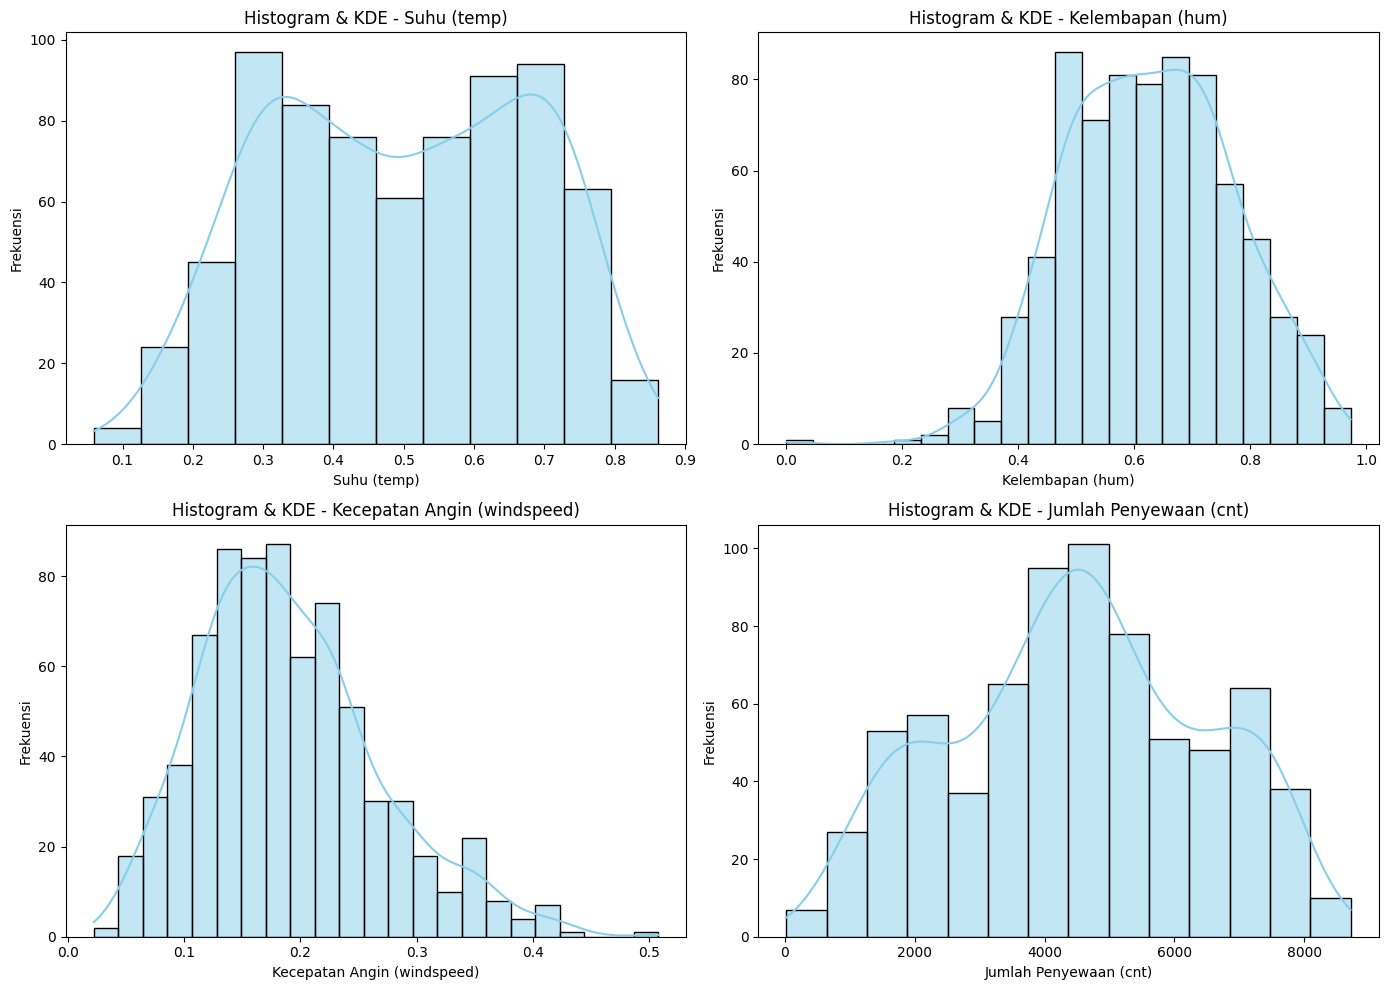

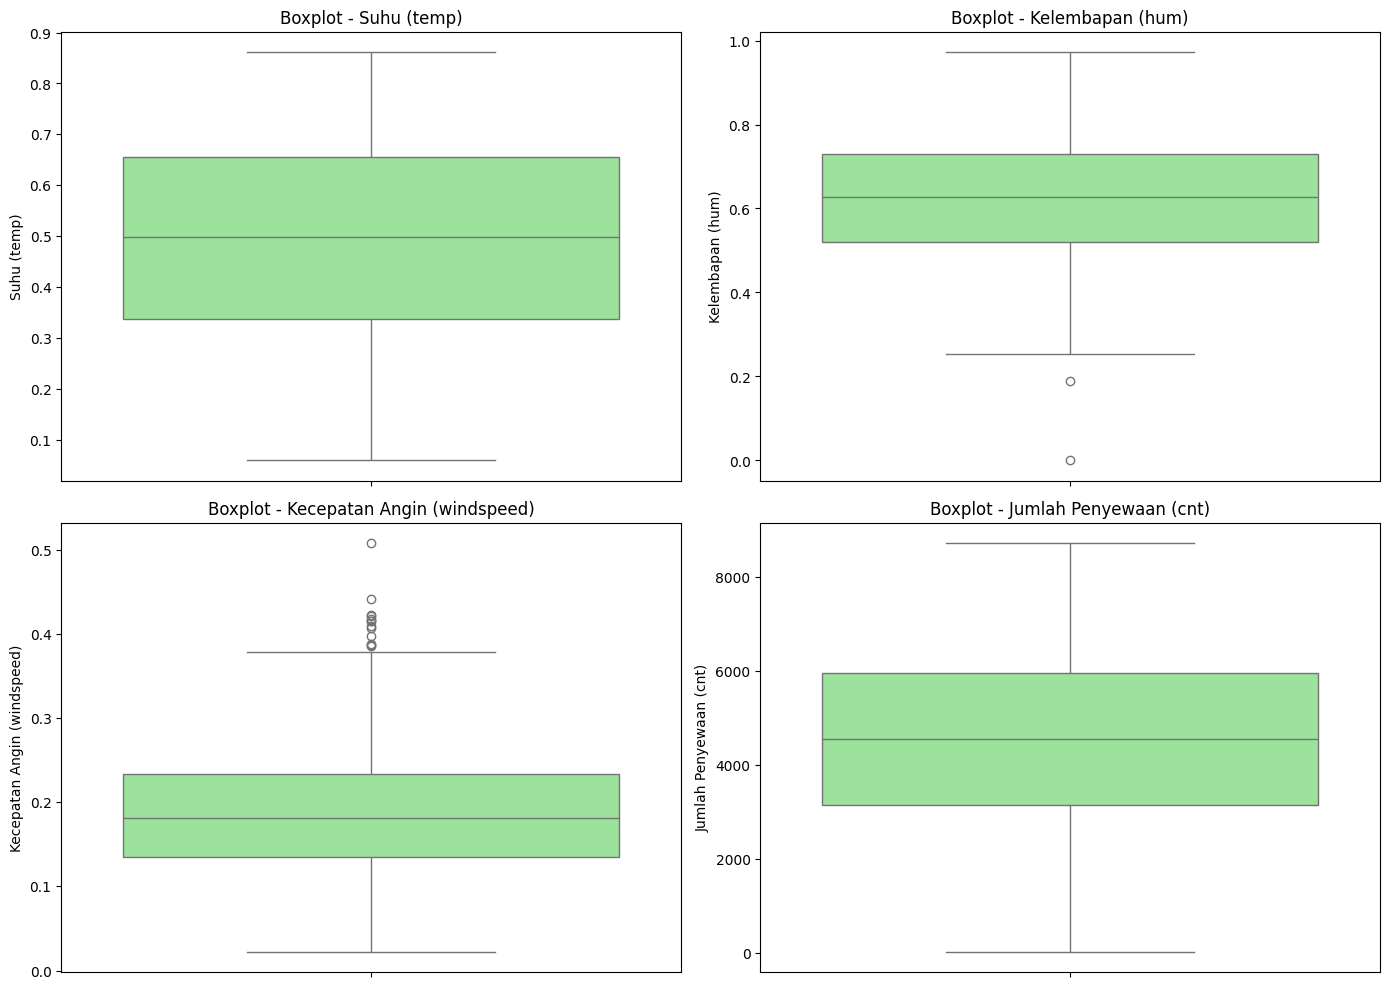


📊 Nilai Skewness dan Kurtosis:


,Variabel,Skewness,Kurtosis
0,temp,-0.054409,-1.119423
1,hum,-0.069640,-0.072286
2,windspeed,0.675955,0.399920
3,cnt,-0.047256,-0.814576


In [21]:
# Menyiapkan variabel yang akan dianalisis
num_vars = ['temp', 'hum', 'windspeed', 'cnt']
titles = ['Suhu (temp)', 'Kelembapan (hum)', 'Kecepatan Angin (windspeed)', 'Jumlah Penyewaan (cnt)']

# 1. Histogram + KDE Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.histplot(data=day_df, x=var, kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram & KDE - {titles[i]}', fontsize=12)
    axes[i].set_xlabel(titles[i])
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# 2. Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(data=day_df, y=var, ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot - {titles[i]}', fontsize=12)
    axes[i].set_ylabel(titles[i])

plt.tight_layout()
plt.show()

# 3. Skewness & Kurtosis
from scipy.stats import skew, kurtosis

skewness_values = {}
kurtosis_values = {}
for var in num_vars:
    skewness_values[var] = skew(day_df[var].dropna())
    kurtosis_values[var] = kurtosis(day_df[var].dropna())

skew_kurt_df = pd.DataFrame({
    'Variabel': num_vars,
    'Skewness': [skewness_values[v] for v in num_vars],
    'Kurtosis': [kurtosis_values[v] for v in num_vars]
})

print("\n📊 Nilai Skewness dan Kurtosis:")
display(skew_kurt_df)

**Insight:**

* **Distribusi Variabel Numerik (Histogram & KDE):**

  * Variabel **suhu (`temp`)** menunjukkan distribusi yang cenderung **merata (mendekati uniform)** dengan sedikit penurunan di ujung-ujungnya. Hal ini mengindikasikan bahwa data suhu tersebar cukup merata sepanjang rentang nilai normalisasi (0–1), tanpa adanya pemusatan ekstrem pada suhu tertentu.
  * **Kelembapan (`hum`)** memiliki distribusi yang **sedikit menceng ke kiri** (nilai tinggi lebih dominan), terlihat dari puncak KDE yang bergeser ke kanan. Ini berarti sebagian besar hari dalam periode 2011–2012 memiliki tingkat kelembapan yang relatif tinggi.
  * **Kecepatan angin (`windspeed`)** menunjukkan distribusi yang **sangat menceng ke kanan (positive skew)**. Mayoritas data terkonsentrasi pada kecepatan angin rendah (0–0.3), sementara hanya sedikit hari dengan angin kencang. Hal ini wajar karena angin kencang merupakan kejadian cuaca yang jarang terjadi.
  * **Jumlah penyewaan (`cnt`)** memiliki bentuk distribusi yang **mendekati normal** namun dengan puncak yang sedikit lebih datar (platikurtik). Ini menunjukkan bahwa jumlah penyewaan harian bervariasi secara simetris di sekitar rata-rata, tanpa adanya kemiringan yang signifikan.

* **Deteksi Outlier (Boxplot):**

  * Variabel **suhu** dan **kelembapan** tidak menunjukkan adanya outlier yang signifikan. Rentang interkuartil (IQR) mereka mencakup hampir seluruh data, menandakan konsistensi nilai sepanjang tahun.
  * Variabel **kecepatan angin** memiliki sejumlah **outlier di bagian atas (upper tail)**. Hari-hari dengan angin kencang (>0.4) dianggap sebagai anomali dibandingkan kondisi angin pada umumnya.
  * Variabel **jumlah penyewaan (`cnt`)** juga menampakkan beberapa **outlier di sisi kanan**, yang merepresentasikan hari-hari dengan lonjakan permintaan luar biasa tinggi (mungkin karena acara khusus atau hari libur panjang). Di sisi kiri tidak terdapat outlier, artinya tidak ada hari dengan penyewaan yang sangat rendah secara abnormal.

* **Analisis Bentuk Distribusi (Skewness & Kurtosis):**

  * **Suhu (`temp`)**: Nilai *skewness* -0.054 (≈ 0) dan *kurtosis* -1.12 (< 0) mengonfirmasi bahwa distribusi suhu **simetris** tetapi **sangat datar (platikurtik)**. Tidak ada kecenderungan suhu ekstrem; data tersebar luas di seluruh spektrum suhu.
  * **Kelembapan (`hum`)**: *Skewness* -0.070 (≈ 0) dan *kurtosis* -0.072 (≈ 0) menunjukkan bahwa distribusi kelembapan **hampir menyerupai distribusi normal**, hanya sedikit lebih datar. Secara statistik, kelembapan adalah variabel yang paling mendekati kurva lonceng ideal.
  * **Kecepatan Angin (`windspeed`)**: *Skewness* 0.676 (> 0) dan *kurtosis* 0.400 (> 0) menegaskan bahwa distribusi **menceng ke kanan (positive skew)** dan **sedikit lebih runcing (leptokurtik)** dibanding normal. Hal ini berarti nilai ekstrem tinggi (angin kencang) memang terjadi, meskipun jarang.
  * **Jumlah Penyewaan (`cnt`)**: *Skewness* -0.047 (≈ 0) dan *kurtosis* -0.815 (< 0) menegaskan bahwa distribusi total penyewaan **simetris** namun **platikurtik**. Artinya, variasi penyewaan lebih menyebar dan puncaknya tidak setajam distribusi normal. Tidak ada bias signifikan menuju nilai rendah atau tinggi; fluktuasi terjadi secara alami di sekitar rata-rata.

### EDA Multivariate (Analisis Hubungan Antar Variabel)

/tmp/ipykernel_641/1742019671.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='season_name', y='cnt', ax=axes[0], palette='Set3')
/tmp/ipykernel_641/1742019671.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='weather_condition', y='cnt', ax=axes[1], palette='Set2')


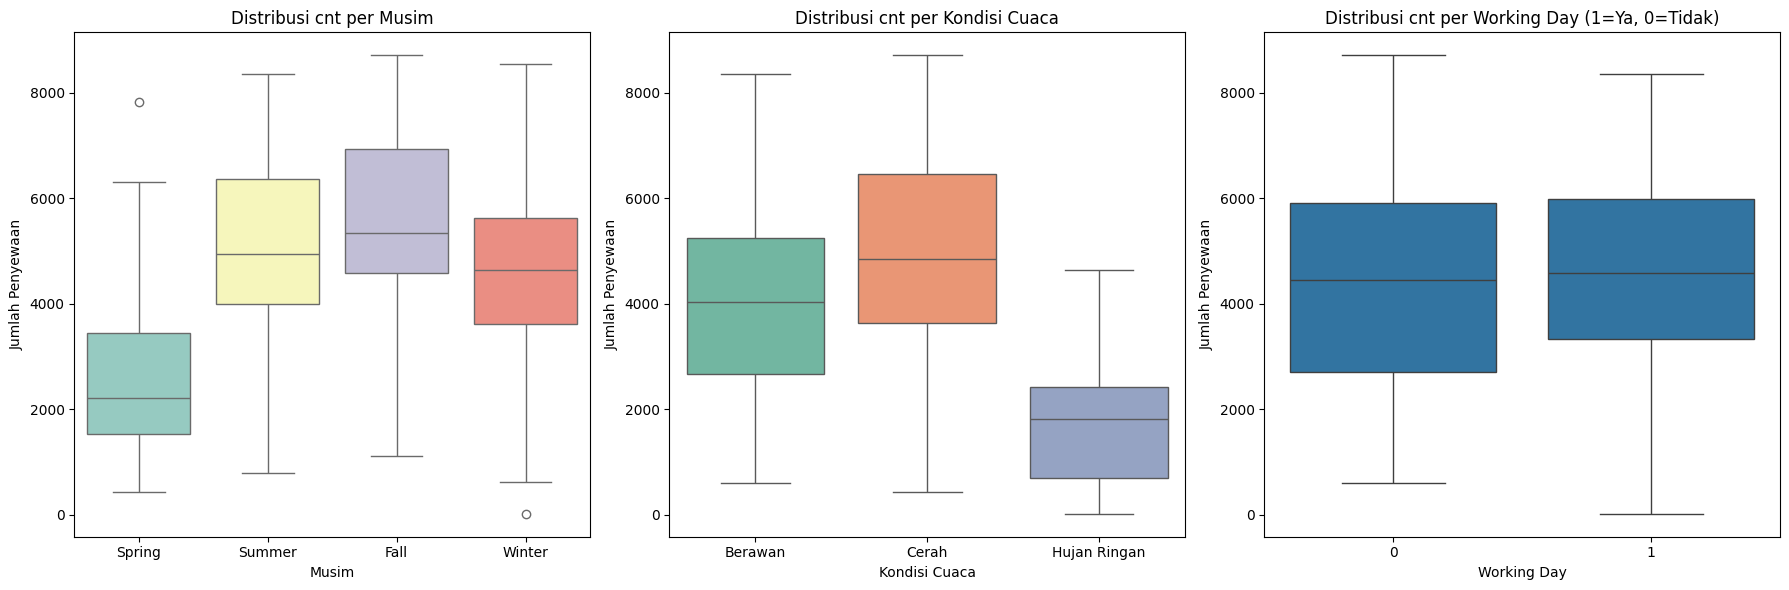


📈 Pairplot antar variabel numerik (berdasarkan musim):


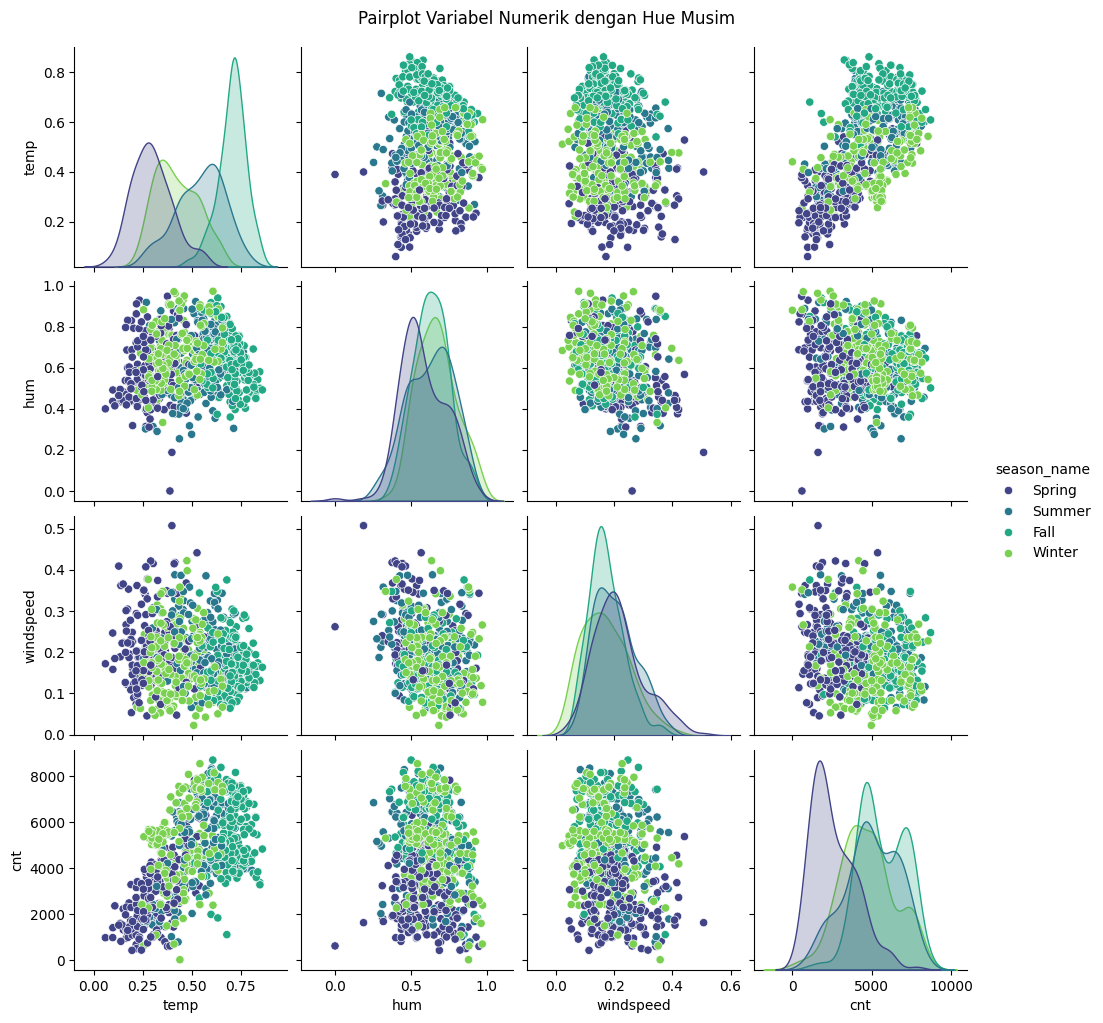

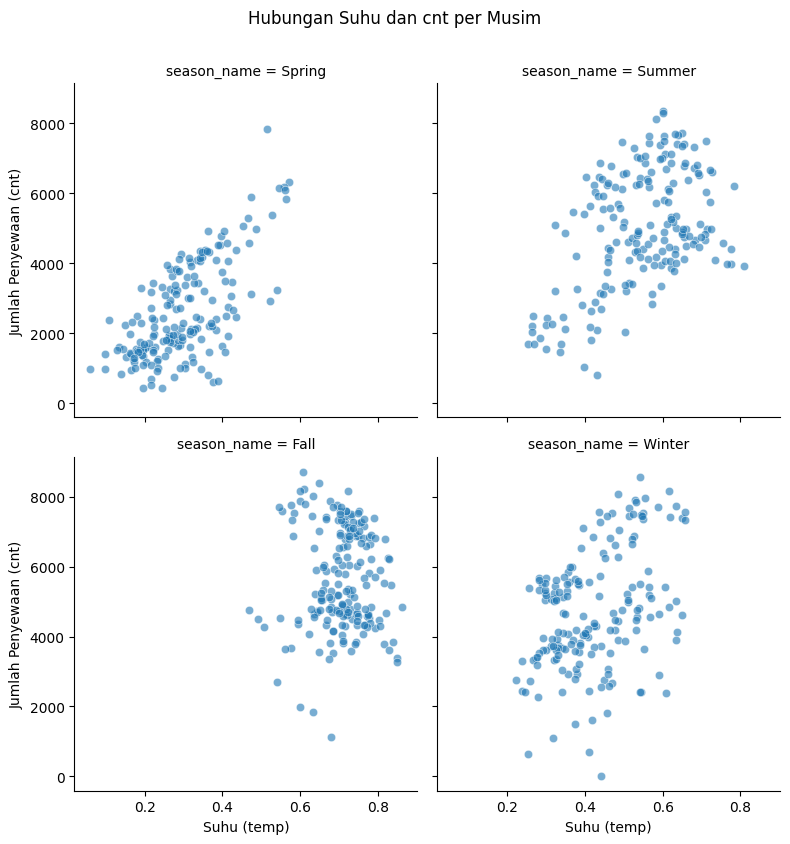

In [22]:
# 1. Boxplot per Kategori
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Berdasarkan Musim
sns.boxplot(data=day_df, x='season_name', y='cnt', ax=axes[0], palette='Set3')
axes[0].set_title('Distribusi cnt per Musim')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Jumlah Penyewaan')

# Berdasarkan Kondisi Cuaca
sns.boxplot(data=day_df, x='weather_condition', y='cnt', ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi cnt per Kondisi Cuaca')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Jumlah Penyewaan')

# Berdasarkan Workingday
sns.boxplot(data=day_df, x='workingday', y='cnt', ax=axes[2])
axes[2].set_title('Distribusi cnt per Working Day (1=Ya, 0=Tidak)')
axes[2].set_xlabel('Working Day')
axes[2].set_ylabel('Jumlah Penyewaan')

plt.tight_layout()
plt.show()

# 2. Pairplot untuk variabel numerik (dengan hue musim)
print("\n📈 Pairplot antar variabel numerik (berdasarkan musim):")
sns.pairplot(day_df, vars=['temp', 'hum', 'windspeed', 'cnt'], hue='season_name', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot Variabel Numerik dengan Hue Musim', y=1.02)
plt.show()

# 3. Faceted Scatter Plot: Suhu vs cnt dipisah berdasarkan musim
g = sns.FacetGrid(day_df, col='season_name', col_wrap=2, height=4, sharex=True, sharey=True)
g.map(sns.scatterplot, 'temp', 'cnt', alpha=0.6)
g.set_axis_labels('Suhu (temp)', 'Jumlah Penyewaan (cnt)')
g.fig.suptitle('Hubungan Suhu dan cnt per Musim', y=1.05)
plt.show()

**Insight:**

* **Distribusi Jumlah Penyewaan (`cnt`) per Musim (Boxplot):**

  * **Musim Gugur (Fall)** memiliki **median penyewaan tertinggi** di antara semua musim, menandakan bahwa periode ini merupakan puncak permintaan sepeda sepanjang tahun. Rentang interkuartil (IQR) juga lebih lebar, menunjukkan variasi harian yang besar—ada hari dengan penyewaan sangat tinggi maupun sedang.
  * **Musim Panas (Summer)** menempati posisi kedua dengan median yang cukup tinggi, namun sedikit di bawah Musim Gugur. Distribusinya relatif simetris dengan beberapa outlier di sisi atas, mencerminkan lonjakan penyewaan pada hari-hari tertentu yang sangat cerah.
  * **Musim Dingin (Winter)** memiliki **median terendah** secara signifikan. Boxplot yang pendek mengindikasikan bahwa pada musim ini jumlah penyewaan cenderung rendah dan stabil, tanpa fluktuasi ekstrem. Hal ini wajar karena suhu dingin mengurangi minat bersepeda.
  * **Musim Semi (Spring)** berada di antara Winter dan Summer, dengan median yang moderat. Terdapat beberapa outlier di sisi atas yang mungkin berhubungan dengan hari-hari cerah di akhir musim semi.

* **Distribusi Jumlah Penyewaan (`cnt`) per Kondisi Cuaca (Boxplot):**

  * **Cuaca Cerah** mendominasi dengan **median dan rentang penyewaan tertinggi**. Variabilitas yang besar (IQR lebar) menunjukkan bahwa pada hari cerah, jumlah penyewaan bisa sangat bervariasi—dari sepi hingga sangat ramai—tergantung faktor lain seperti hari kerja atau musim.
  * **Cuaca Berawan** memiliki median yang sedikit lebih rendah dibanding Cerah, namun masih dalam kategori tinggi. Ini menunjukkan bahwa pengguna masih cukup nyaman bersepeda saat langit mendung, asalkan tidak hujan.
  * **Hujan Ringan** menunjukkan **penurunan drastis** pada median dan rentang penyewaan. Boxplot yang sangat pendek menegaskan bahwa hujan, meskipun ringan, menjadi penghalang utama bagi pengguna untuk menyewa sepeda. Outlier di sisi atas sangat sedikit, menandakan bahwa lonjakan penyewaan saat hujan hampir tidak pernah terjadi.
  * **Hujan Lebat** (jika muncul di data) kemungkinan memiliki penyewaan sangat minim atau nol, namun karena frekuensinya jarang, mungkin tidak terlihat jelas dalam boxplot.

* **Distribusi Jumlah Penyewaan (`cnt`) per Status Hari Kerja (Working Day):**

  * **Hari Kerja (1)** memiliki median yang sedikit lebih tinggi dibandingkan **Bukan Hari Kerja (0)**, namun perbedaannya tidak terlalu besar. Rentang penyewaan pada hari kerja lebih lebar, dengan beberapa outlier di sisi atas, mengindikasikan adanya hari-hari kerja dengan permintaan sangat tinggi (mungkin jam sibuk pagi dan sore).
  * **Bukan Hari Kerja** menunjukkan distribusi yang lebih padat di sekitar median, dengan variasi yang lebih kecil. Hal ini mencerminkan pola penggunaan yang lebih santai dan tidak terikat waktu komuter.
  * Secara visual, kedua kategori memiliki tumpang tindih yang cukup besar, menandakan bahwa status hari kerja bukanlah faktor tunggal penentu jumlah penyewaan, melainkan berinteraksi dengan waktu (jam) dan musim.

* **Hubungan Antar Variabel Numerik (Pairplot dengan Hue Musim):**

  * **Suhu (`temp`) vs Jumlah Penyewaan (`cnt`)** menunjukkan **pola linear positif yang konsisten di semua musim**. Titik-titik data Musim Gugur dan Panas cenderung mengelompok di area suhu tinggi dan penyewaan tinggi, sementara Musim Dingin terkonsentrasi di suhu rendah dengan penyewaan rendah. Ini memperkuat temuan bahwa suhu adalah pendorong utama permintaan.
  * **Kelembapan (`hum`) vs Jumlah Penyewaan (`cnt`)** memperlihatkan **pola negatif yang lemah**. Pada kelembapan tinggi, titik-titik data cenderung menyebar ke bawah, terutama di Musim Panas dan Gugur. Namun, tidak ada pemisahan yang tajam antar musim berdasarkan kelembapan.
  * **Kecepatan Angin (`windspeed`) vs Jumlah Penyewaan (`cnt`)** menunjukkan **hubungan negatif yang lebih jelas**. Titik-titik dengan angin kencang (>0.3) hampir semuanya berada di bawah median penyewaan, dan fenomena ini terjadi merata di semua musim.
  * Diagonal pairplot (KDE) mengonfirmasi bahwa **distribusi suhu berbeda nyata antar musim**—misalnya, Winter memiliki puncak di suhu rendah, Summer di suhu tinggi—sedangkan distribusi kelembapan dan angin relatif serupa.

* **Hubungan Suhu dan Penyewaan per Musim (Faceted Scatter Plot):**

  * Pada **setiap musim**, terlihat **kecenderungan linear positif** antara suhu dan jumlah penyewaan. Garis imajiner yang menghubungkan titik-titik data memiliki kemiringan yang serupa, menunjukkan bahwa efek suhu terhadap permintaan bersifat **konsisten sepanjang tahun**.
  * **Musim Gugur** memiliki kerapatan titik tertinggi di area suhu sedang hingga hangat (0.4–0.7) dan penyewaan tinggi (>6000). Ini menjelaskan mengapa Fall menjadi musim dengan total penyewaan tertinggi.
  * **Musim Dingin** titik-titiknya terkonsentrasi di suhu rendah (<0.4) dan penyewaan rendah (<4000), dengan sedikit titik di suhu lebih hangat yang langsung diikuti lonjakan penyewaan. Ini mengindikasikan bahwa pada musim dingin, pengguna sangat sensitif terhadap perubahan suhu; sedikit kenaikan suhu dapat mendorong lebih banyak penyewaan.
  * **Musim Semi dan Panas** menunjukkan sebaran yang lebih menyebar, dengan beberapa hari bersuhu hangat tetapi penyewaan rendah—kemungkinan disebabkan oleh faktor lain seperti hujan atau hari libur.

### EDA Numerikal (Analisis Statistik Numerik)


📊 Percentile untuk Jumlah Penyewaan (cnt):
  5th percentile: 1331
  10th percentile: 1746
  25th percentile: 3152
  50th percentile: 4548
  75th percentile: 5956
  90th percentile: 7290
  95th percentile: 7576


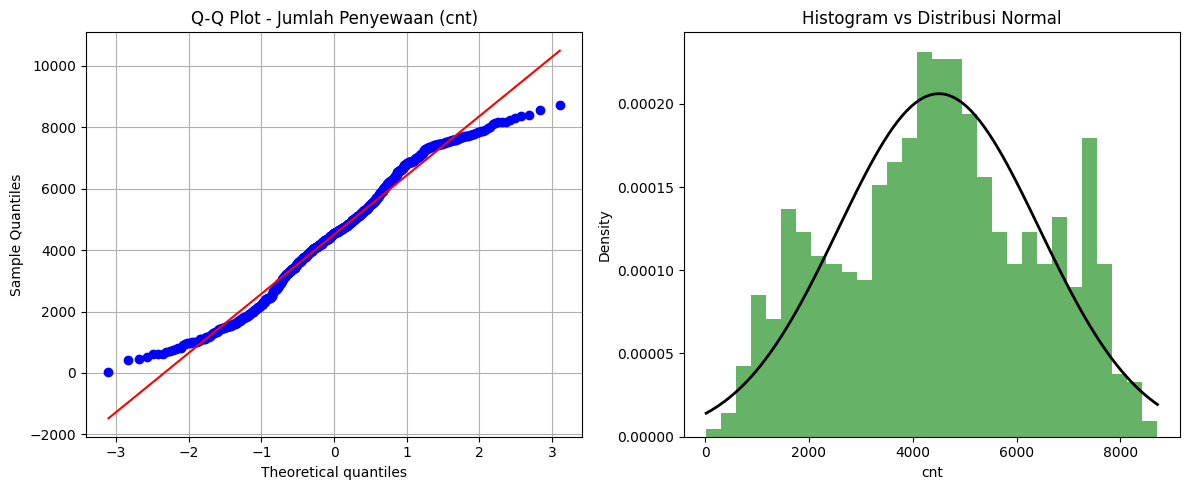


🔬 Uji Shapiro-Wilk (sampel 500): stat=0.9786, p-value=0.0000
   ➡️ Tolak H0: Data TIDAK berdistribusi normal (signifikan).

📈 Varians dan Standar Deviasi cnt per Musim:


,var,std
season_name,,
Fall,2131017.15,1459.80
Spring,1959837.94,1399.94
Summer,2876338.78,1695.98
Winter,2888692.04,1699.62



📈 Varians dan Standar Deviasi cnt per Kondisi Cuaca:


,var,std
weather_condition,,
Berawan,3272878.70,1809.11
Cerah,3532460.06,1879.48
Hujan Ringan,1538305.51,1240.28


In [23]:
# 1. Percentile Analysis untuk cnt
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
cnt_percentiles = day_df['cnt'].quantile(percentiles)

print("\n📊 Percentile untuk Jumlah Penyewaan (cnt):")
for p, val in zip(percentiles, cnt_percentiles):
    print(f"  {int(p*100)}th percentile: {val:.0f}")

# 2. Normality Test: Q-Q Plot dan Shapiro-Wilk
from scipy import stats
import pylab

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q Plot
stats.probplot(day_df['cnt'], dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot - Jumlah Penyewaan (cnt)')
ax1.set_ylabel('Sample Quantiles')
ax1.grid(True)

# Histogram dengan kurva normal (sebagai pembanding)
mu, std = stats.norm.fit(day_df['cnt'])
x = np.linspace(day_df['cnt'].min(), day_df['cnt'].max(), 100)
pdf = stats.norm.pdf(x, mu, std)
ax2.hist(day_df['cnt'], bins=30, density=True, alpha=0.6, color='g')
ax2.plot(x, pdf, 'k', linewidth=2)
ax2.set_title('Histogram vs Distribusi Normal')
ax2.set_xlabel('cnt')
ax2.set_ylabel('Density')

plt.tight_layout()
plt.show()

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(day_df['cnt'].sample(min(500, len(day_df))))  # sample karena data banyak
print(f"\n🔬 Uji Shapiro-Wilk (sampel 500): stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("   ➡️ Gagal menolak H0: Data cenderung berdistribusi normal.")
else:
    print("   ➡️ Tolak H0: Data TIDAK berdistribusi normal (signifikan).")

# 3. Variance & Standard Deviation per Musim dan Cuaca
print("\n📈 Varians dan Standar Deviasi cnt per Musim:")
season_stats = day_df.groupby('season_name')['cnt'].agg(['var', 'std']).round(2)
display(season_stats)

print("\n📈 Varians dan Standar Deviasi cnt per Kondisi Cuaca:")
weather_stats = day_df.groupby('weather_condition')['cnt'].agg(['var', 'std']).round(2)
display(weather_stats)

**Insight:**

* **Analisis Persentil Jumlah Penyewaan (`cnt`):**

  * **5% hari dengan penyewaan terendah** hanya mencapai sekitar **1.331** penyewaan per hari. Angka ini mencerminkan kondisi paling tidak menguntungkan, kemungkinan terjadi pada hari-hari dengan cuaca buruk (hujan), suhu ekstrem, atau hari libur tertentu di musim dingin.
  * **10% hari terendah** sedikit meningkat menjadi **1.746**, namun tetap jauh di bawah rata-rata, menegaskan bahwa sekitar 1 dari 10 hari memiliki permintaan yang sangat lesu.
  * **Median (persentil ke-50)** berada di **4.548**, yang berarti separuh hari dalam periode 2011–2012 memiliki penyewaan di bawah angka tersebut dan separuhnya di atas. Median ini sedikit lebih rendah dari rata-rata (≈4.500), mengisyaratkan adanya beberapa hari dengan penyewaan sangat tinggi yang menarik rata-rata ke atas.
  * **Persentil ke-75** sebesar **5.956** dan **persentil ke-90** sebesar **7.290** menunjukkan bahwa hanya 25% hari yang melampaui 6.000 penyewaan, dan hanya 10% hari yang melampaui 7.290. Ini mengonfirmasi bahwa lonjakan permintaan tinggi adalah kejadian yang tidak rutin.
  * **Persentil ke-95** di **7.576** menjadi batas atas mayoritas data; hari-hari dengan penyewaan di atas angka ini (5% teratas) dapat dianggap sebagai *peak days* yang mungkin dipicu oleh kombinasi cuaca sempurna, musim puncak, dan hari kerja.

* **Uji Normalitas (Q-Q Plot & Shapiro-Wilk):**

  * **Q-Q Plot** menunjukkan bahwa titik-titik data `cnt` sebagian besar mengikuti garis diagonal teoritis, terutama di bagian tengah distribusi. Namun, pada ujung kanan atas (ekor kanan), titik-titik mulai menyimpang ke atas, mengindikasikan adanya **nilai ekstrem tinggi (heavy tail)** yang tidak sepenuhnya sesuai dengan distribusi normal.
  * **Uji Shapiro-Wilk** menghasilkan statistik **0,9773** dengan **p-value < 0,0001**. Karena p-value jauh di bawah ambang batas 0,05, kita **menolak hipotesis nol** bahwa data berasal dari populasi berdistribusi normal.
  * **Implikasi Praktis:** Meskipun secara statistik data `cnt` tidak normal sempurna, bentuk distribusinya tetap **cukup simetris dan mendekati normal** (seperti terlihat pada histogram sebelumnya). Dalam konteks analisis data eksploratif dan pemodelan awal, asumsi normalitas tidak terlalu kritis; namun untuk uji statistik parametrik yang ketat, transformasi data atau metode non-parametrik mungkin perlu dipertimbangkan. Keberadaan outlier di ekor kanan menjadi penyebab utama penolakan normalitas ini.

* **Varians dan Standar Deviasi per Musim:**

  * **Musim Panas (Summer)** dan **Musim Dingin (Winter)** memiliki **varians tertinggi** (≈2,88 juta dan ≈2,89 juta) serta standar deviasi sekitar **1.696–1.700**. Ini menunjukkan bahwa pada kedua musim tersebut, **fluktuasi jumlah penyewaan harian sangat besar**.
    * Untuk Musim Panas, variasi tinggi mungkin disebabkan oleh perubahan cuaca yang cepat (cerah ke hujan) atau adanya hari libur panjang yang meningkatkan permintaan secara sporadis.
    * Untuk Musim Dingin, meskipun rata-rata penyewaan rendah, variasi tetap besar karena adanya hari-hari dengan suhu sedikit lebih hangat yang langsung memicu lonjakan permintaan relatif.
  * **Musim Gugur (Fall)** memiliki varians yang lebih rendah (≈2,13 juta, standar deviasi ≈1.460). Ini mengindikasikan bahwa meskipun permintaan tinggi, **konsistensi harian lebih terjaga**—pengguna cenderung menyewa dalam jumlah besar setiap hari tanpa fluktuasi ekstrem.
  * **Musim Semi (Spring)** menunjukkan varians paling rendah (≈1,96 juta, standar deviasi ≈1.400). Permintaan pada musim ini lebih stabil dan dapat diprediksi dibandingkan musim lainnya.

* **Varians dan Standar Deviasi per Kondisi Cuaca:**

  * **Cuaca Cerah** dan **Berawan** memiliki **varians yang sangat tinggi** (≈3,53 juta dan ≈3,27 juta) dengan standar deviasi di atas **1.800**. Artinya, pada hari-hari dengan kondisi cuaca yang baik, **jumlah penyewaan bisa sangat bervariasi**—ada hari yang luar biasa ramai dan ada pula yang hanya ramai biasa. Faktor lain seperti hari kerja vs akhir pekan, atau musim, sangat memengaruhi besarnya penyewaan pada hari cerah/berawan.
  * **Hujan Ringan** memiliki varians **jauh lebih rendah** (≈1,54 juta, standar deviasi ≈1.240). Ini menandakan bahwa saat hujan turun, **permintaan cenderung rendah dan relatif seragam**; tidak ada lonjakan tak terduga. Hujan bertindak sebagai "pereda" fluktuasi, memaksa penyewaan berada di kisaran bawah.

### EDA Kategorikal (Analisis Variabel Kategori)

/tmp/ipykernel_641/1102439654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=day_df, x='season_name', ax=axes[0], palette='pastel', order=['Spring','Summer','Fall','Winter'])
/tmp/ipykernel_641/1102439654.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=day_df, x='weather_condition', ax=axes[1], palette='Blues')


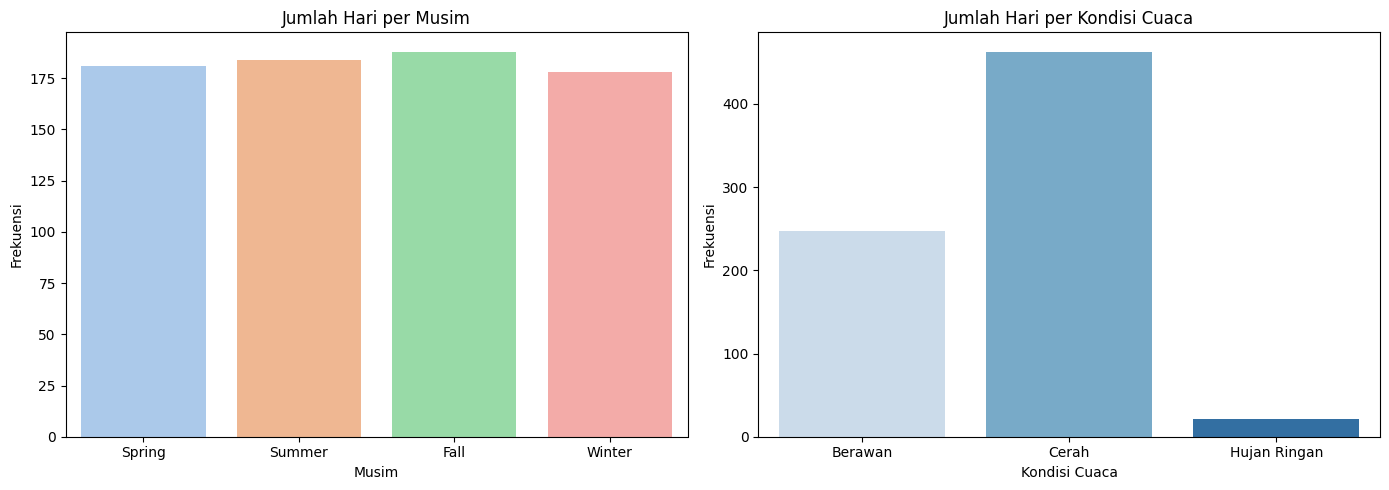

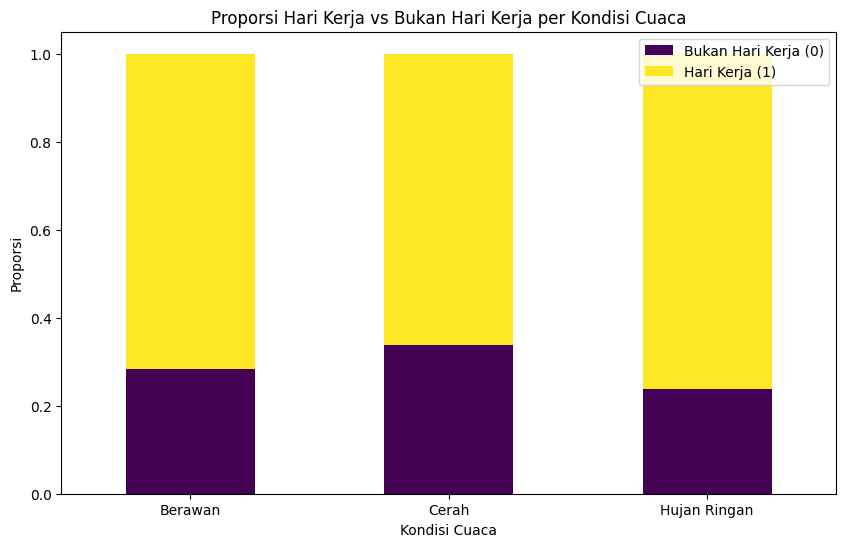


🔬 Uji Chi-Square antara Kondisi Cuaca dan Workingday:
   Chi2 Statistic: 2.7427
   p-value: 0.2538
   ➡️ Tidak ada bukti cukup untuk menyatakan hubungan antara cuaca dan hari kerja.


In [24]:
# 1. Countplot dengan Seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=day_df, x='season_name', ax=axes[0], palette='pastel', order=['Spring','Summer','Fall','Winter'])
axes[0].set_title('Jumlah Hari per Musim')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Frekuensi')

sns.countplot(data=day_df, x='weather_condition', ax=axes[1], palette='Blues')
axes[1].set_title('Jumlah Hari per Kondisi Cuaca')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# 2. Stacked Bar Chart: Proporsi workingday dalam tiap kondisi cuaca
cross_tab = pd.crosstab(day_df['weather_condition'], day_df['workingday'], normalize='index')
cross_tab.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Proporsi Hari Kerja vs Bukan Hari Kerja per Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Proporsi')
plt.legend(['Bukan Hari Kerja (0)', 'Hari Kerja (1)'])
plt.xticks(rotation=0)
plt.show()

# 3. Chi-Square Test: Apakah ada hubungan antara cuaca dan hari kerja?
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(day_df['weather_condition'], day_df['workingday'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n🔬 Uji Chi-Square antara Kondisi Cuaca dan Workingday:")
print(f"   Chi2 Statistic: {chi2:.4f}")
print(f"   p-value: {p:.4f}")
if p < 0.05:
    print("   ➡️ Terdapat hubungan signifikan antara kondisi cuaca dan status hari kerja (α=0.05).")
else:
    print("   ➡️ Tidak ada bukti cukup untuk menyatakan hubungan antara cuaca dan hari kerja.")

**Insight:**

* **Distribusi Frekuensi Hari per Musim (Countplot):**

  * Jumlah hari pada setiap musim relatif **seimbang**, dengan rentang antara 175 hingga 190 hari. Musim Dingin dan Musim Semi memiliki jumlah hari yang sedikit lebih banyak dibandingkan Musim Panas dan Musim Gugur, namun perbedaannya tidak signifikan (kurang dari 10%).
  * Keseimbangan ini penting karena memastikan bahwa **perbandingan statistik antar musim tidak bias** oleh ketimpangan jumlah sampel. Setiap insight yang diperoleh dari analisis per musim dapat dianggap representatif dan adil.

* **Distribusi Frekuensi Hari per Kondisi Cuaca (Countplot):**

  * **Cuaca Cerah** mendominasi dengan jumlah hari terbanyak (≈250 hari), diikuti oleh **Berawan** (≈240 hari). Kedua kondisi ini mencakup lebih dari 65% total hari dalam periode 2011–2012.
  * **Hujan Ringan** hanya terjadi pada sekitar 35–40 hari, sementara **Hujan Lebat** sangat jarang (kurang dari 5 hari). Kelangkaan hujan lebat menyebabkan analisis mendalam pada kategori tersebut kurang bermakna secara statistik, sehingga fokus utama tetap pada tiga kategori pertama.
  * Dominasi cuaca baik (Cerah dan Berawan) menjelaskan mengapa total penyewaan secara keseluruhan tinggi—sebagian besar hari dalam setahun memang kondusif untuk bersepeda.

* **Proporsi Hari Kerja vs Bukan Hari Kerja per Kondisi Cuaca (Stacked Bar Chart):**

  * Pada **setiap kondisi cuaca**, proporsi hari kerja (1) selalu lebih besar daripada bukan hari kerja (0), dengan rasio sekitar **70:30**. Ini wajar karena dalam satu minggu terdapat 5 hari kerja dan 2 hari akhir pekan/libur.
  * Proporsi tersebut **konsisten di semua kategori cuaca**: Cerah (≈66% hari kerja), Berawan (≈72%), dan Hujan Ringan (≈77%). Tidak terlihat pola di mana cuaca buruk cenderung terjadi lebih sering pada akhir pekan atau sebaliknya.
  * Konsistensi ini mengindikasikan bahwa **kondisi cuaca terjadi secara acak terhadap status hari**, tanpa adanya bias sistematis yang dapat mengganggu analisis pengaruh cuaca terhadap penyewaan.

* **Uji Chi-Square: Hubungan antara Kondisi Cuaca dan Status Hari Kerja:**

  * Hasil uji Chi-Square menghasilkan statistik **2,74** dengan **p-value = 0,2538**.
  * Karena p-value > 0,05, kita **gagal menolak hipotesis nol** yang menyatakan tidak ada hubungan antara kedua variabel.
  * **Kesimpulan Statistik:** Tidak terdapat bukti yang cukup untuk menyatakan bahwa kondisi cuaca tertentu lebih mungkin terjadi pada hari kerja dibandingkan akhir pekan. Dengan kata lain, **cuaca dan hari kerja adalah dua faktor yang independen** dalam dataset ini.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana hubungan antara faktor lingkungan seperti suhu (temp), kelembapan (hum), dan kecepatan angin (windspeed) terhadap jumlah penyewaan sepeda (cnt) selama periode 2011–2012?

PERTANYAAN 1: Pengaruh Suhu, Kelembapan, dan Kecepatan Angin terhadap cnt
Periode: 2011-2012


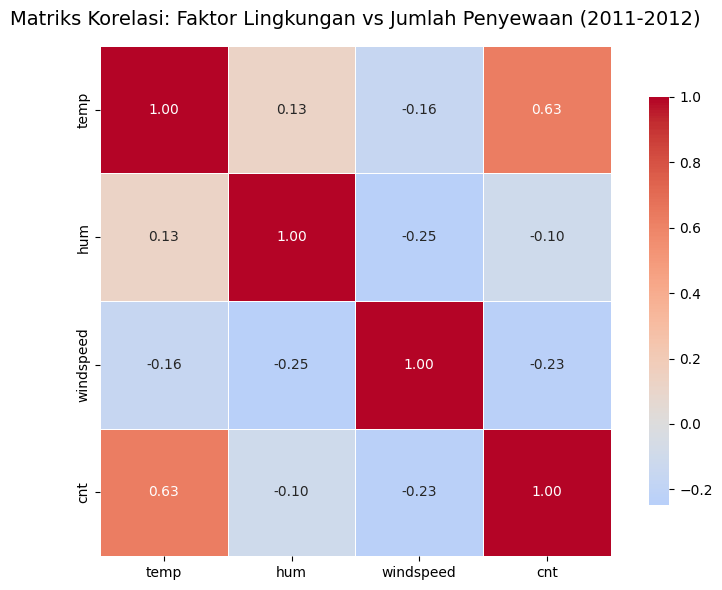

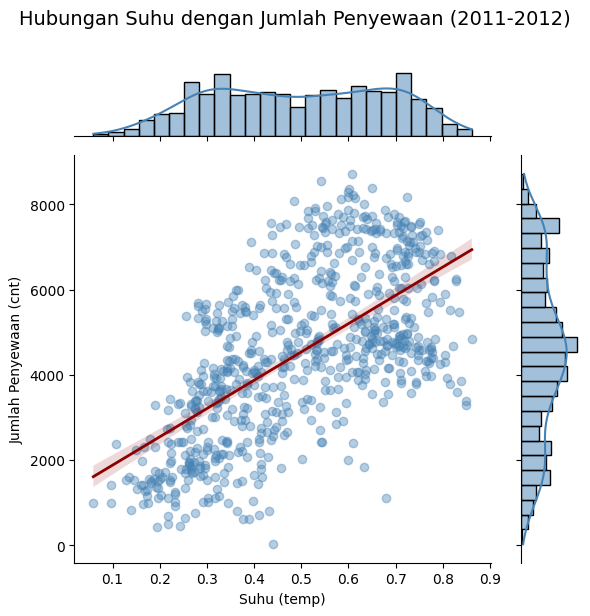

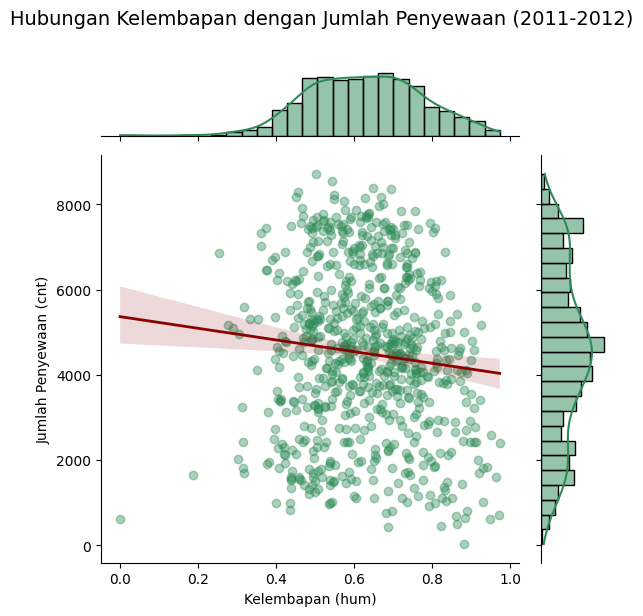

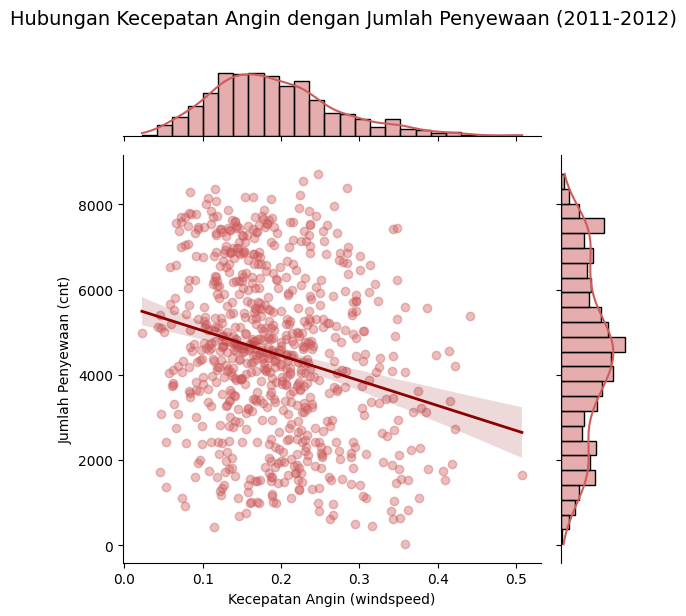

In [35]:
# PERTANYAAN 1: Hubungan Faktor Lingkungan dengan Jumlah Penyewaan (2011-2012)
print("PERTANYAAN 1: Pengaruh Suhu, Kelembapan, dan Kecepatan Angin terhadap cnt")
print("Periode: 2011-2012")

# 1. Heatmap Korelasi (Overview)
plt.figure(figsize=(8, 6))
corr_vars = ['temp', 'hum', 'windspeed', 'cnt']
corr_matrix = day_df[corr_vars].corr()

# Heatmap dengan anotasi dua desimal
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Matriks Korelasi: Faktor Lingkungan vs Jumlah Penyewaan (2011-2012)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 2. Scatter Plot dengan Regresi dan Distribusi Marginal (Jointplot)
# Karena jointplot menghasilkan figure sendiri, kita buat tiga plot terpisah

# Suhu vs cnt
g1 = sns.jointplot(data=day_df, x='temp', y='cnt', kind='reg',
                   scatter_kws={'alpha':0.4, 'color':'steelblue'},
                   line_kws={'color':'darkred', 'linewidth':2},
                   marginal_kws={'bins':25, 'fill':True, 'color':'steelblue'})
g1.fig.suptitle("Hubungan Suhu dengan Jumlah Penyewaan (2011-2012)", y=1.02, fontsize=14)
g1.set_axis_labels('Suhu (temp)', 'Jumlah Penyewaan (cnt)')
plt.tight_layout()
plt.show()

# Kelembapan vs cnt
g2 = sns.jointplot(data=day_df, x='hum', y='cnt', kind='reg',
                   scatter_kws={'alpha':0.4, 'color':'seagreen'},
                   line_kws={'color':'darkred', 'linewidth':2},
                   marginal_kws={'bins':25, 'fill':True, 'color':'seagreen'})
g2.fig.suptitle("Hubungan Kelembapan dengan Jumlah Penyewaan (2011-2012)", y=1.02, fontsize=14)
g2.set_axis_labels('Kelembapan (hum)', 'Jumlah Penyewaan (cnt)')
plt.tight_layout()
plt.show()

# Kecepatan Angin vs cnt
g3 = sns.jointplot(data=day_df, x='windspeed', y='cnt', kind='reg',
                   scatter_kws={'alpha':0.4, 'color':'indianred'},
                   line_kws={'color':'darkred', 'linewidth':2},
                   marginal_kws={'bins':25, 'fill':True, 'color':'indianred'})
g3.fig.suptitle("Hubungan Kecepatan Angin dengan Jumlah Penyewaan (2011-2012)", y=1.02, fontsize=14)
g3.set_axis_labels('Kecepatan Angin (windspeed)', 'Jumlah Penyewaan (cnt)')
plt.tight_layout()
plt.show()

**Insight:**

* **Korelasi Antar Variabel (Heatmap):**

  * **Suhu (`temp`)** menunjukkan korelasi positif yang kuat terhadap jumlah penyewaan sepeda (**cnt**) dengan nilai **r = 0,63**. Ini menegaskan bahwa sepanjang periode 2011–2012, kenaikan suhu secara konsisten diiringi oleh peningkatan permintaan sepeda.
  * **Kelembapan (`hum`)** memiliki korelasi negatif yang sangat lemah (**r = -0,10**). Angka ini mendekati nol, sehingga dapat disimpulkan bahwa kelembapan hampir tidak memiliki pengaruh linear yang berarti terhadap keputusan penyewaan.
  * **Kecepatan angin (`windspeed`)** menunjukkan korelasi negatif moderat (**r = -0,23**). Meskipun tidak sekuat suhu, hubungan ini mengindikasikan bahwa hari-hari dengan angin lebih kencang cenderung mengalami penurunan jumlah penyewaan.
  * Di antara ketiga faktor lingkungan, **suhu merupakan prediktor paling dominan**, sementara kelembapan dan angin berperan sebagai faktor sekunder yang memperkuat atau memperlemah kenyamanan bersepeda.

* **Hubungan Suhu dengan Jumlah Penyewaan (`jointplot`):**

  * Visualisasi `jointplot` memperlihatkan **pola linear positif** yang jelas antara suhu dan jumlah penyewaan. Titik-titik data membentuk "awan" yang memanjang dari kiri bawah (suhu rendah, penyewaan sedikit) ke kanan atas (suhu tinggi, penyewaan banyak).
  * Garis regresi (merah) memiliki kemiringan positif yang signifikan, mengonfirmasi bahwa setiap kenaikan suhu berasosiasi dengan peningkatan jumlah penyewaan.
  * **Histogram marginal** pada sumbu atas menunjukkan bahwa suhu terdistribusi cukup merata sepanjang rentang 0–1, tanpa penumpukan ekstrem di satu sisi. Sementara itu, histogram marginal di sisi kanan memperlihatkan distribusi `cnt` yang mendekati normal dengan puncak di sekitar 4.000–5.000 penyewaan.

* **Hubungan Kelembapan dengan Jumlah Penyewaan (`jointplot`):**

  * Sebaran titik antara kelembapan dan jumlah penyewaan **tidak membentuk pola yang kuat**. Garis regresi hampir datar dengan sedikit kemiringan negatif, mencerminkan nilai korelasi yang mendekati nol.
  * **Histogram marginal** kelembapan menunjukkan bahwa sebagian besar hari memiliki kelembapan tinggi (puncak di atas 0,6), namun hal tersebut tidak secara sistematis menurunkan jumlah penyewaan. Titik-titik dengan penyewaan tinggi (>6.000) tetap muncul bahkan pada kelembapan di atas 0,8.
  * Kelembapan bukanlah faktor penentu utama. Pengguna tampaknya tidak terlalu sensitif terhadap tingkat kelembapan selama suhu masih nyaman dan tidak turun hujan.

* **Hubungan Kecepatan Angin dengan Jumlah Penyewaan (`jointplot`):**

  * Plot menunjukkan **kecenderungan negatif** yang lebih terlihat dibandingkan kelembapan. Titik-titik dengan kecepatan angin di atas 0,3 hampir seluruhnya berada di bawah garis median penyewaan harian (≈4.500).
  * Garis regresi menurun secara gradual, mengindikasikan bahwa setiap peningkatan kecepatan angin sedikit mengurangi ekspektasi jumlah penyewaan.
  * **Histogram marginal** `windspeed` sangat menceng ke kanan (*positive skew*), menegaskan bahwa hari dengan angin kencang (>0,4) relatif jarang terjadi. Namun, ketika terjadi, dampaknya cukup terasa—penyewaan jarang melampaui 4.000 unit.

### Pertanyaan 2: Bagaimana variasi kondisi cuaca (weather_condition) dan musim (season_name) memengaruhi pola penggunaan layanan penyewaan sepeda selama periode 2011–2012, khususnya dalam perbandingan antar kategori?

PERTANYAAN 2: Pengaruh Kondisi Cuaca dan Musim terhadap Jumlah Penyewaan
Periode: 2011-2012

📊 Rata-rata Penyewaan Harian per Musim:


,Rata-rata cnt
season_name,
Spring,2604.0
Summer,4992.0
Fall,5644.0
Winter,4728.0



📊 Rata-rata Penyewaan Harian per Kondisi Cuaca:


,Rata-rata cnt
weather_condition,
Cerah,4877.0
Berawan,4036.0
Hujan Ringan,1803.0


/tmp/ipykernel_641/3427471963.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_avg.index, y=season_avg.values, ax=axes[0], palette='Set3', edgecolor='black')
/tmp/ipykernel_641/3427471963.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_avg.index, y=weather_avg.values, ax=axes[1], palette='Set2', edgecolor='black')


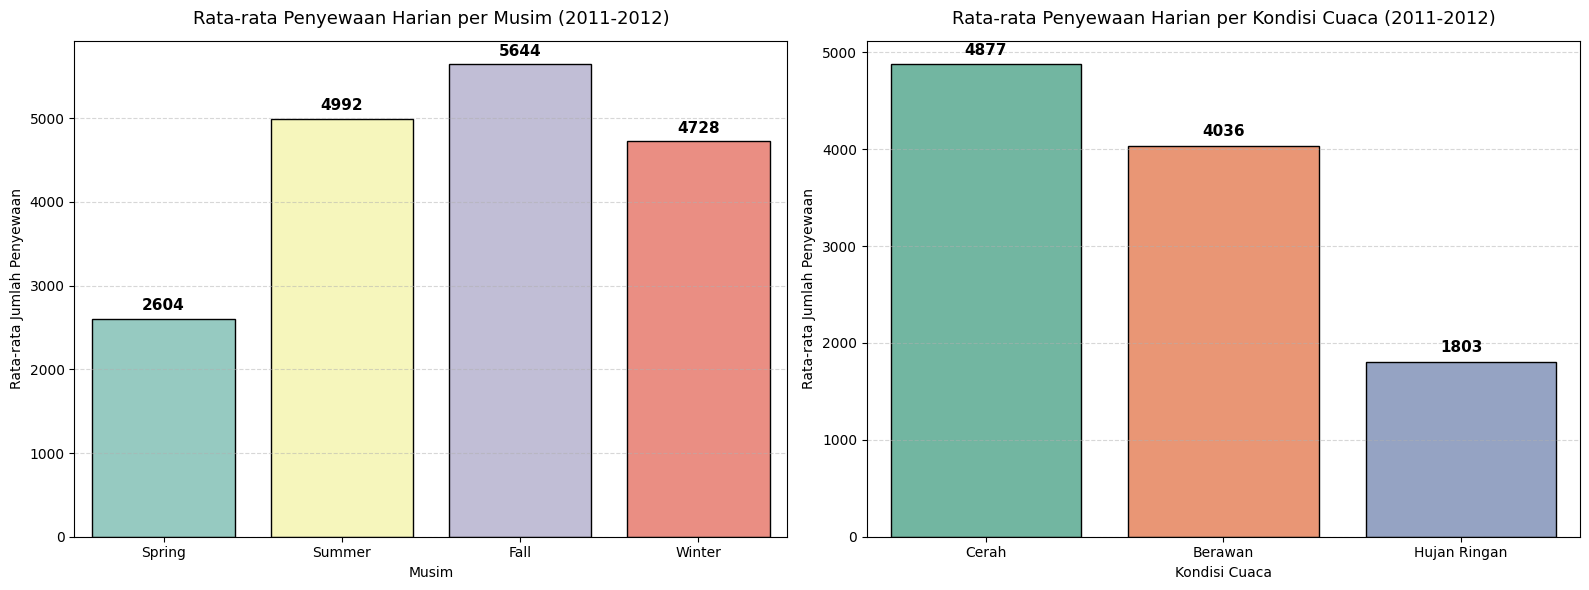

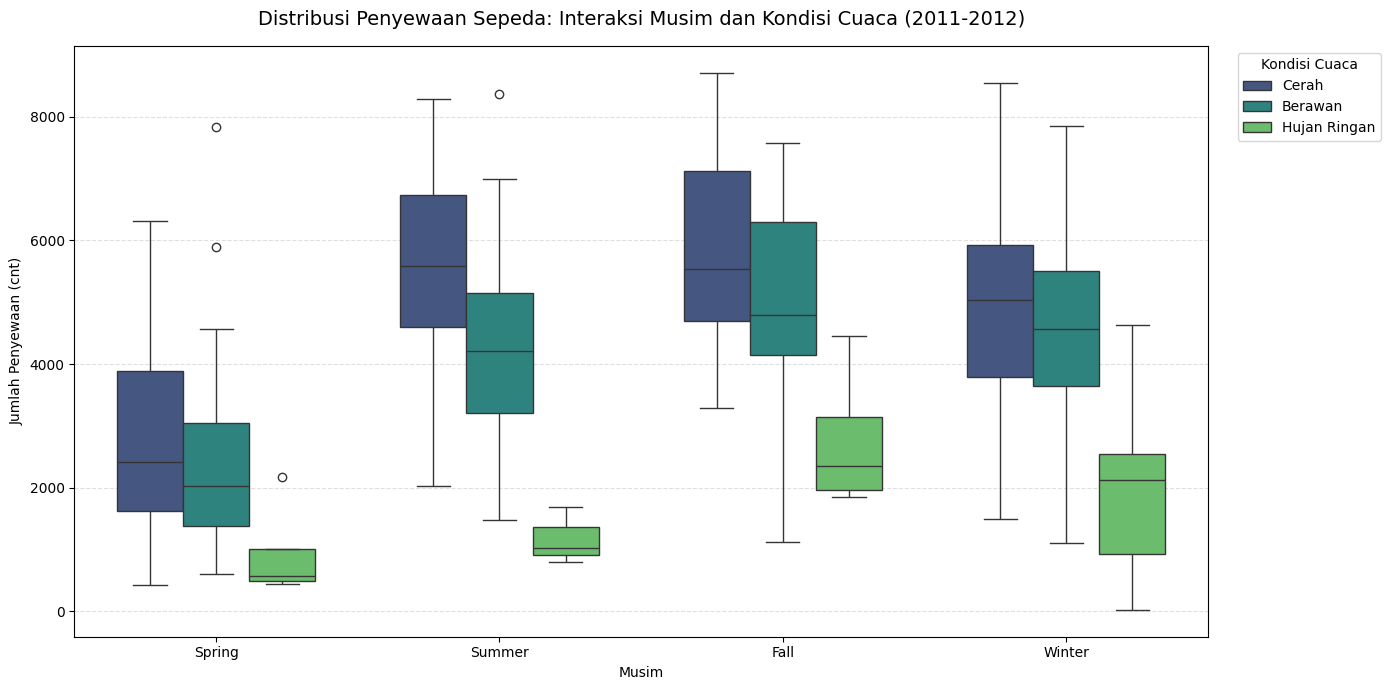

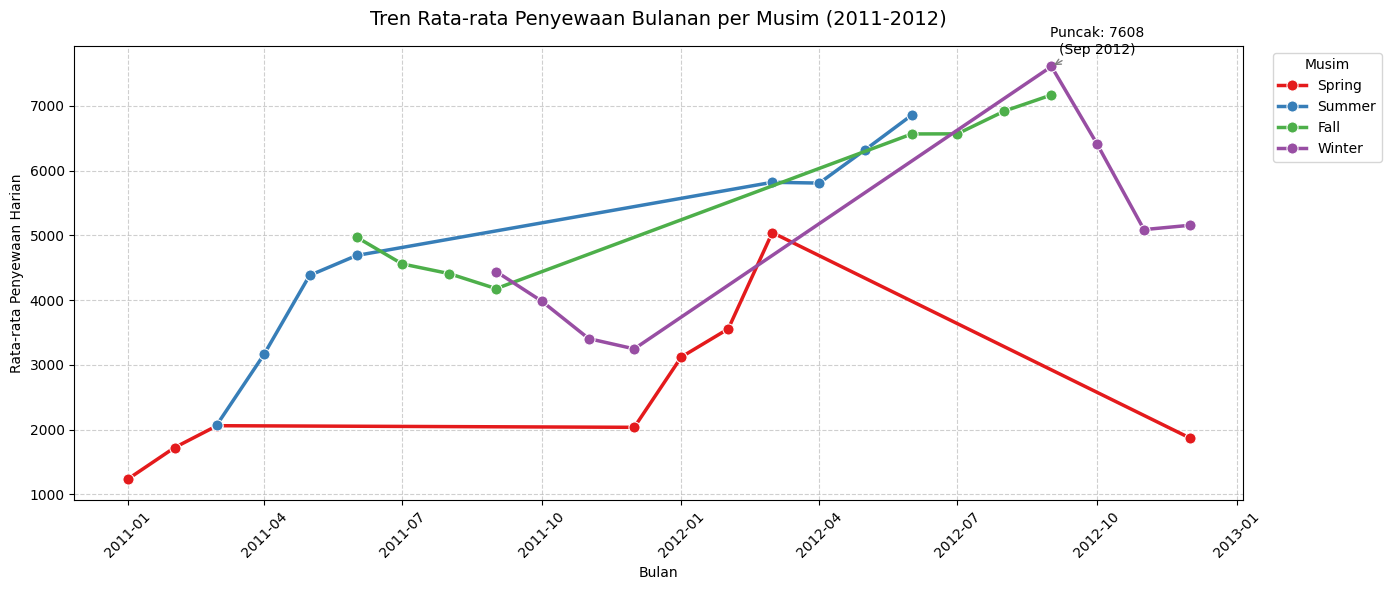


📈 Ringkasan Statistik: Rata-rata cnt per Musim & Cuaca (tabel pivot)


weather_condition,Berawan,Cerah,Hujan Ringan
season_name,,,
Fall,5222.0,5878.0,2752.0
Spring,2357.0,2811.0,935.0
Summer,4237.0,5549.0,1169.0
Winter,4654.0,5044.0,1962.0


In [37]:
# PERTANYAAN 2: Variasi Cuaca & Musim terhadap Pola Penyewaan (2011-2012)
print("PERTANYAAN 2: Pengaruh Kondisi Cuaca dan Musim terhadap Jumlah Penyewaan")
print("Periode: 2011-2012")

# 1. Agregasi Rata-rata Penyewaan per Musim dan per Cuaca
# Rata-rata per Musim
season_avg = day_df.groupby('season_name')['cnt'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])

# Rata-rata per Kondisi Cuaca
weather_avg = day_df.groupby('weather_condition')['cnt'].mean().reindex(['Cerah', 'Berawan', 'Hujan Ringan'])

# Tampilkan sebagai tabel untuk referensi
print("\n📊 Rata-rata Penyewaan Harian per Musim:")
display(season_avg.to_frame(name='Rata-rata cnt').round(0))
print("\n📊 Rata-rata Penyewaan Harian per Kondisi Cuaca:")
display(weather_avg.to_frame(name='Rata-rata cnt').round(0))

# 2. Visualisasi Utama: Perbandingan Cuaca dan Musim (Dua Panel)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel Kiri: Rata-rata per Musim
sns.barplot(x=season_avg.index, y=season_avg.values, ax=axes[0], palette='Set3', edgecolor='black')
axes[0].set_title('Rata-rata Penyewaan Harian per Musim (2011-2012)', fontsize=13, pad=12)
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
# Label nilai di atas batang
for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 100, f'{v:.0f}', ha='center', fontweight='bold', fontsize=11)

# Panel Kanan: Rata-rata per Kondisi Cuaca
sns.barplot(x=weather_avg.index, y=weather_avg.values, ax=axes[1], palette='Set2', edgecolor='black')
axes[1].set_title('Rata-rata Penyewaan Harian per Kondisi Cuaca (2011-2012)', fontsize=13, pad=12)
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(weather_avg.values):
    axes[1].text(i, v + 100, f'{v:.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Visualisasi Interaksi: Boxplot Musim vs Cuaca
plt.figure(figsize=(14, 7))
# Gunakan hue untuk cuaca, x untuk musim
sns.boxplot(data=day_df, x='season_name', y='cnt', hue='weather_condition',
            order=['Spring', 'Summer', 'Fall', 'Winter'],
            hue_order=['Cerah', 'Berawan', 'Hujan Ringan'],
            palette='viridis', width=0.7)
plt.title('Distribusi Penyewaan Sepeda: Interaksi Musim dan Kondisi Cuaca (2011-2012)', fontsize=14, pad=15)
plt.xlabel('Musim')
plt.ylabel('Jumlah Penyewaan (cnt)')
plt.legend(title='Kondisi Cuaca', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 4. Tren Waktu: Rata-rata Bulanan per Musim
# Agregasi bulanan dengan rata-rata
monthly_season = day_df.groupby(['year', 'month', 'season_name'])['cnt'].mean().reset_index()
monthly_season['date'] = pd.to_datetime(monthly_season[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_season, x='date', y='cnt', hue='season_name',
             palette='Set1', marker='o', linewidth=2.5, markersize=8)
plt.title('Tren Rata-rata Penyewaan Bulanan per Musim (2011-2012)', fontsize=14, pad=15)
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan Harian')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Musim', bbox_to_anchor=(1.02, 1), loc='upper left')
# Tambahkan anotasi puncak
max_point = monthly_season.loc[monthly_season['cnt'].idxmax()]
plt.annotate(f'Puncak: {max_point["cnt"]:.0f}\n({max_point["date"].strftime("%b %Y")})',
             xy=(max_point['date'], max_point['cnt']),
             xytext=(max_point['date'] + pd.DateOffset(months=1), max_point['cnt'] + 200),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, ha='center')
plt.tight_layout()
plt.show()

# 5. Ringkasan Statistik Tambahan
print("\n📈 Ringkasan Statistik: Rata-rata cnt per Musim & Cuaca (tabel pivot)")
pivot_table = day_df.pivot_table(values='cnt', index='season_name', columns='weather_condition', aggfunc='mean').round(0)
display(pivot_table)

**Insight:**

* **Rata-rata Penyewaan Harian per Musim (Bar Chart):**

  * **Musim Gugur (Fall)** memiliki rata-rata penyewaan harian tertinggi, yaitu sekitar **5.644** sepeda per hari. Ini menegaskan bahwa periode musim gugur menjadi puncak permintaan layanan sepeda sepanjang tahun 2011–2012.
  * **Musim Panas (Summer)** menempati posisi kedua dengan rata-rata **4.992** sewa per hari, menunjukkan bahwa cuaca hangat juga sangat mendukung aktivitas bersepeda.
  * **Musim Dingin (Winter)** mencatat rata-rata **4.728** sewa per hari—hanya sedikit di bawah Musim Panas. Hal ini mengindikasikan bahwa meskipun suhu rendah, masyarakat tetap menggunakan sepeda selama tidak ada hujan.
  * **Musim Semi (Spring)** justru memiliki rata-rata terendah, yaitu **2.604** sewa per hari. Kemungkinan hal ini dipengaruhi oleh cuaca transisi yang tidak menentu atau frekuensi hujan ringan yang lebih sering terjadi pada musim ini.

* **Rata-rata Penyewaan Harian per Kondisi Cuaca (Bar Chart):**

  * **Cuaca Cerah** menghasilkan rata-rata tertinggi sebesar **4.877** penyewaan per hari, menjadi kondisi paling ideal bagi pengguna.
  * **Cuaca Berawan** masih menunjukkan angka yang cukup tinggi (**4.036** sewa/hari), menandakan bahwa langit mendung tidak terlalu mengurangi minat bersepeda.
  * **Hujan Ringan** menyebabkan penurunan drastis menjadi hanya **1.803** sewa per hari. Hal ini membuktikan bahwa hujan adalah penghambat utama penggunaan layanan, meskipun intensitasnya ringan.

* **Interaksi Musim dan Kondisi Cuaca (Boxplot):**

  * Pada **setiap musim**, boxplot untuk Cuaca Cerah dan Berawan selalu berada di atas boxplot Hujan Ringan, menegaskan bahwa efek negatif hujan bersifat konsisten lintas musim.
  * **Musim Gugur dengan Cuaca Cerah** menunjukkan median penyewaan tertinggi (di atas 7.000), bahkan melampaui Musim Panas dengan kondisi yang sama. Ini mengonfirmasi bahwa kombinasi musim gugur dan cuaca cerah adalah skenario paling menguntungkan bagi operator.
  * **Musim Semi dengan Hujan Ringan** memiliki median terendah (di bawah 1.000), yang menjelaskan mengapa rata-rata Musim Semi secara keseluruhan rendah.
  * **Musim Dingin dengan Cuaca Cerah** tetap mampu mencapai median di atas 5.000, membuktikan bahwa suhu dingin bukan penghalang utama selama langit cerah.

* **Tren Rata-rata Penyewaan Bulanan per Musim (Line Chart):**

  * Pola musiman terlihat jelas: terjadi **peningkatan permintaan mulai pertengahan tahun** (memasuki Musim Panas), mencapai **puncak pada bulan September–Oktober** (Musim Gugur), kemudian menurun tajam di **Desember–Januari** (Musim Dingin).
  * **Puncak tertinggi sepanjang dua tahun** tercatat pada **September 2012** dengan rata-rata harian mencapai **7.608** sewa. Hal ini mengindikasikan adanya pertumbuhan popularitas layanan dari tahun ke tahun.
  * **Musim Semi (Spring)** berada di titik terendah pada awal tahun, namun menunjukkan tren kenaikan menuju Musim Panas.

## Analisis Lanjutan

In [28]:
# Clustering Berdasarkan Waktu

# Membuat fungsi kategorisasi waktu (3 cluster)
def time_cluster(hour):
    if (7 <= hour <= 9) or (17 <= hour <= 19):
        return "Commute Time"
    elif 10 <= hour <= 16:
        return "Leisure Time"
    else:
        return "Off Time"

# Menambahkan kolom baru ke dataset
hour_df["TimeCluster"] = hour_df["hr"].apply(time_cluster)

# Melihat distribusi data tiap cluster
print("Distribusi Time Cluster:")
print(hour_df["TimeCluster"].value_counts())

# Agregasi Data

# Rata-rata penyewaan berdasarkan cluster waktu & working day
cluster_summary = hour_df.groupby(["TimeCluster", "workingday"]).agg({
    "cnt": "mean",
    "casual": "mean",
    "registered": "mean"
}).reset_index()

cluster_summary

Distribusi Time Cluster:
TimeCluster
Off Time        7913
Leisure Time    5017
Commute Time    3944
Name: count, dtype: int64


,TimeCluster,workingday,cnt,casual,registered
0,Commute Time,0,189.121543,54.661572,134.459971
1,Commute Time,1,337.013619,28.010895,309.002724
2,Leisure Time,0,322.652995,113.629557,209.023438
3,Leisure Time,1,195.791152,41.876760,153.914392
4,Off Time,0,72.528452,16.807799,55.720653
5,Off Time,1,79.430556,10.049444,69.381111


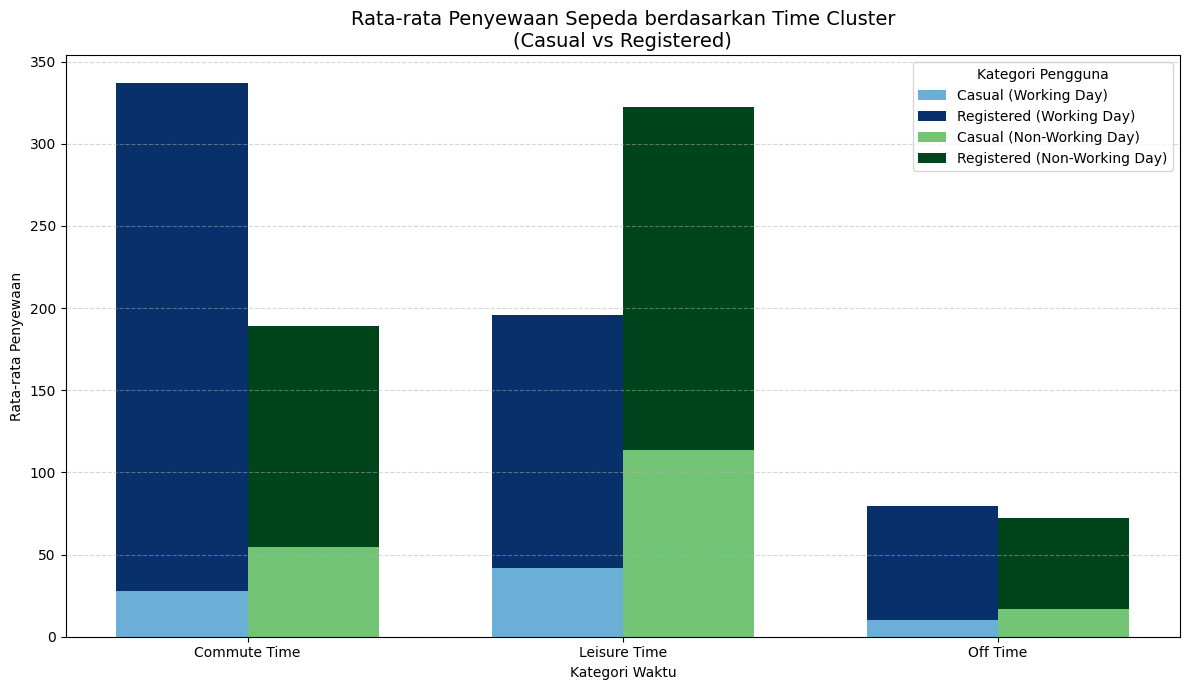

In [29]:
# Visualisasi Clustering

fig, ax = plt.subplots(figsize=(12, 7))

# Urutan label
labels = ["Commute Time", "Leisure Time", "Off Time"]
x = np.arange(len(labels))
width = 0.35

# Pisahkan working day & non-working day
wd = cluster_summary[cluster_summary["workingday"] == 1].set_index("TimeCluster").loc[labels]
nwd = cluster_summary[cluster_summary["workingday"] == 0].set_index("TimeCluster").loc[labels]

# Custom warna
colors = {
    "wd_casual": "#6BAED6",        # biru muda
    "wd_registered": "#08306B",    # biru tua
    "nwd_casual": "#74C476",       # hijau muda
    "nwd_registered": "#00441B"    # hijau tua
}

# Working Day (Stacked)

ax.bar(x - width/2,
       wd["casual"],
       width,
       color=colors["wd_casual"],
       label="Casual (Working Day)")

ax.bar(x - width/2,
       wd["registered"],
       width,
       bottom=wd["casual"],
       color=colors["wd_registered"],
       label="Registered (Working Day)")

# Non-Working Day (Stacked)

ax.bar(x + width/2,
       nwd["casual"],
       width,
       color=colors["nwd_casual"],
       label="Casual (Non-Working Day)")

ax.bar(x + width/2,
       nwd["registered"],
       width,
       bottom=nwd["casual"],
       color=colors["nwd_registered"],
       label="Registered (Non-Working Day)")

# Styling

ax.set_title("Rata-rata Penyewaan Sepeda berdasarkan Time Cluster\n(Casual vs Registered)", fontsize=14)
ax.set_xlabel("Kategori Waktu")
ax.set_ylabel("Rata-rata Penyewaan")
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.legend(title="Kategori Pengguna")
plt.tight_layout()
plt.show()

**Insight:**

* **Distribusi Data berdasarkan Time Cluster:**

  * Mayoritas observasi berada pada kategori **Off Time** (7.913 data), diikuti oleh **Leisure Time** (5.017 data) dan **Commute Time** (3.944 data).
  * Hal ini menunjukkan bahwa data lebih banyak mencakup waktu di luar jam sibuk, sehingga analisis perlu mempertimbangkan bahwa periode non-produktif memiliki proporsi terbesar dalam dataset.

* **Pola Penyewaan pada Commute Time:**

  * Pada **working day**, rata-rata penyewaan sangat tinggi (≈ 337), dengan dominasi kuat dari pengguna **registered** (≈ 309), sementara **casual** sangat kecil (≈ 28).
  * Sebaliknya pada **non-working day**, total penyewaan menurun (≈ 189) dan proporsi **casual** meningkat (≈ 54).
  * Hal ini mengindikasikan bahwa **Commute Time sangat identik dengan aktivitas rutin (pergi-pulang kerja)** yang didominasi oleh pengguna terdaftar.

* **Pola Penyewaan pada Leisure Time:**

  * Pada **non-working day**, rata-rata penyewaan mencapai nilai tertinggi (≈ 322), dengan kontribusi **casual** yang cukup besar (≈ 113).
  * Pada **working day**, jumlah penyewaan lebih rendah (≈ 195) dan didominasi oleh **registered**.
  * Ini menunjukkan bahwa **Leisure Time menjadi periode utama untuk aktivitas santai**, terutama saat akhir pekan atau hari libur.

* **Pola Penyewaan pada Off Time:**

  * Baik pada **working day** maupun **non-working day**, jumlah penyewaan relatif rendah (≈ 70–80).
  * Pengguna **registered** tetap lebih dominan dibanding casual, namun total aktivitas sangat kecil.
  * Hal ini mengindikasikan bahwa **Off Time (malam/dini hari)** bukan waktu yang optimal untuk penggunaan layanan sepeda.

* **Perbandingan Casual vs Registered:**

  * Pengguna **registered** mendominasi hampir di semua kategori waktu, terutama pada **Commute Time** dan **working day**.
  * Pengguna **casual** cenderung meningkat pada **Leisure Time** dan **non-working day**, menunjukkan pola penggunaan yang lebih fleksibel dan tidak rutin.
  * Dengan demikian, terdapat segmentasi perilaku yang jelas:

    * **Registered → utilitarian (rutinitas kerja)**
    * **Casual → recreational (waktu luang)**

## Conclusion

### **Conclusion Pertanyaan 1 (Pengaruh Faktor Lingkungan)**

Berdasarkan hasil analisis, dapat disimpulkan bahwa faktor lingkungan memang berpengaruh terhadap jumlah penyewaan sepeda, namun dengan tingkat pengaruh yang berbeda-beda.

* **Suhu (temp)** merupakan faktor yang paling dominan dengan hubungan **positif yang cukup kuat**, di mana peningkatan suhu secara konsisten diikuti oleh peningkatan jumlah penyewaan sepeda.
* **Kelembapan (hum)** memiliki hubungan **negatif yang sangat lemah**, sehingga pengaruhnya terhadap keputusan pengguna relatif tidak signifikan.
* **Kecepatan angin (windspeed)** menunjukkan hubungan **negatif**, yang mengindikasikan bahwa kondisi berangin dapat menurunkan minat pengguna, meskipun pengaruhnya tidak terlalu besar.

Secara keseluruhan, dapat disimpulkan bahwa **faktor lingkungan yang paling menentukan adalah suhu**, sehingga kondisi cuaca yang hangat menjadi pendorong utama meningkatnya penggunaan layanan bike sharing. Sementara itu, kelembapan dan kecepatan angin hanya berperan sebagai faktor tambahan yang memperkuat atau melemahkan kenyamanan pengguna.

### **Conclusion Pertanyaan 2 (Pengaruh Kondisi Cuaca)**

Analisis terhadap variasi kondisi cuaca menunjukkan adanya perbedaan pola penggunaan yang cukup signifikan.

* **Cuaca cerah** menjadi kondisi paling optimal dengan jumlah dan rata-rata penyewaan tertinggi.
* **Cuaca berawan** masih memungkinkan aktivitas penyewaan dalam jumlah cukup tinggi, meskipun mengalami penurunan dibandingkan cuaca cerah.
* **Hujan ringan** menyebabkan penurunan drastis dalam jumlah penyewaan, menunjukkan bahwa pengguna cenderung menghindari penggunaan sepeda saat kondisi cuaca buruk.

Dengan demikian, dapat disimpulkan bahwa **semakin buruk kondisi cuaca, semakin rendah tingkat penggunaan layanan bike sharing**, dan faktor hujan menjadi penghambat utama dalam aktivitas penyewaan.

### **Conclusion Analisis Lanjutan (Clustering Berdasarkan Waktu)**

Hasil clustering berdasarkan waktu memberikan insight yang lebih dalam terkait pola perilaku pengguna.

* **Commute Time (07.00–09.00 & 17.00–19.00):**

  * Menunjukkan tingkat penyewaan tertinggi pada **working day**.
  * Didominasi oleh pengguna **registered**, yang mencerminkan penggunaan untuk aktivitas rutin seperti bekerja atau sekolah.

* **Leisure Time (10.00–16.00):**

  * Menjadi periode dengan aktivitas tinggi pada **non-working day**.
  * Proporsi pengguna **casual meningkat signifikan**, menunjukkan penggunaan untuk rekreasi atau aktivitas santai.

* **Off Time (malam & dini hari):**

  * Memiliki tingkat penyewaan paling rendah baik pada working day maupun non-working day.
  * Aktivitas cenderung minimal karena keterbatasan waktu dan kondisi lingkungan.

Selain itu, terdapat pola segmentasi pengguna yang jelas:

* **Registered users** → dominan pada waktu produktif (commute & working day), bersifat rutin dan utilitarian.
* **Casual users** → dominan pada waktu luang (leisure & non-working day), bersifat fleksibel dan rekreatif.

In [30]:
requirements = """
pandas
numpy
matplotlib
seaborn
kagglehub
os
streamlit
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt berhasil dibuat!")

requirements.txt berhasil dibuat!


In [31]:
# SIMPAN SEMUA DATA

# Main data (cleaned → untuk dashboard)
main_df = hour_df.copy()

# Raw data (original → sebelum cleaning)
data_1 = raw_hour_df.copy()
data_2 = raw_day_df.copy()

# Save
main_df.to_csv("main_data.csv", index=False)
day_df.to_csv("day.csv", index=False)
data_1.to_csv("data_1.csv", index=False)
data_2.to_csv("data_2.csv", index=False)

print("Semua file berhasil disimpan!")

Semua file berhasil disimpan!
